# Detecção de Fornos de Tijolo em Imagens de Satélite

### Global Solution — Visão Computacional na Indústria Espacial (Applied Computer Vision)

**Integrantes:**
- Lucas Rodrigues da Silva | RM: 98344
- Juan Pinheiro de França  | RM: 552202
- Kaiky Alvaro de Miranda  | RM: 98118

---

###  Definição do problema e conexão com a Global Solution

Fornos de tijolo artesanais (*brick kilns*) estão ligados a **poluição do ar,
desmatamento, mineração irregular e trabalho análogo à escravidão**. Mapeá-los
manualmente na escala de um país é inviável. Nossa solução usa **observação da Terra
por satélite** — um produto direto da **indústria espacial** — para **detectar e
classificar fornos automaticamente** em imagens do **Sentinel-2 (ESA, ~10 m/pixel)**.

**Tarefa de visão computacional:** dado um *tile* (recorte) de imagem de satélite,
classificá-lo em 4 classes — `none` (sem forno), `CFCBK` (circular), `FCBK`, `Zigzag` —
gerando mapas de ocorrência e tipo de forno para apoiar fiscalização ambiental.

> 🛰️ **Conexão espacial:** o sistema depende de sensores orbitais (Sentinel-2) e
> transforma dados brutos de sensoriamento remoto em informação acionável — uma
> aplicação *downstream* clássica da indústria espacial.
> _[Ajuste este parágrafo para amarrar ao problema específico da sua Global Solution.]_

###  Abordagem

Conforme o edital, treinamos **duas CNNs do zero** (sem *transfer learning*). Em vez de
detecção de objetos (YOLO/U-Net) — difícil de treinar do zero — tratamos o problema
como **classificação de tile**, mais viável e alinhado ao `idea.md`.

Este notebook é **autossuficiente**: suba o `.ipynb` e rode de cima a baixo (ele baixa
o dataset do Kaggle e recria o pacote `kiln_cnn`)..

## 0. Baixar o dataset do Kaggle

Os dados vêm de:
[kaggle.com/datasets/rishabhsnip/sentinelkiln-dataset](https://www.kaggle.com/datasets/rishabhsnip/sentinelkiln-dataset)

**Autenticação (necessária uma vez):**
1. Em [kaggle.com](https://www.kaggle.com) → *Settings → API → Create New Token* (baixa `kaggle.json`).
2. A forma mais simples no Colab é rodar `kagglehub.login()` e colar usuário + token,
   **ou** definir as variáveis de ambiente `KAGGLE_USERNAME` e `KAGGLE_KEY`.

In [1]:
!pip install -q kagglehub

import kagglehub

# Se pedir credenciais, descomente a linha abaixo e autentique:
# kagglehub.login()

DOWNLOAD_DIR = kagglehub.dataset_download("rishabhsnip/sentinelkiln-dataset")
print("Dataset baixado em:", DOWNLOAD_DIR)

100%|██████████| 3.54G/3.54G [03:31<00:00, 18.0MB/s]

Extracting files...


Dataset baixado em: /root/.cache/kagglehub/datasets/rishabhsnip/sentinelkiln-dataset/versions/4


In [2]:
import os

def find_data_root(base):
    """Acha a pasta que contém train/images (lida com subpasta extra do Kaggle)."""
    candidates = [base]
    if os.path.isdir(base):
        candidates += [os.path.join(base, d) for d in os.listdir(base)]
    for c in candidates:
        if os.path.isdir(os.path.join(c, "train", "images")):
            return c
    raise FileNotFoundError(f"Não encontrei train/images dentro de {base}")

ROOT = find_data_root(DOWNLOAD_DIR)
print("ROOT dos dados:", ROOT)

ROOT dos dados: /root/.cache/kagglehub/datasets/rishabhsnip/sentinelkiln-dataset/versions/4


## 1. Recriar o pacote `kiln_cnn` no ambiente

O código do projeto vem embutido aqui em base64 e é escrito em disco. Assim o
notebook funciona sozinho no Colab (sem precisar subir a pasta `kiln_cnn/` à parte).
Se você **já** tem o pacote disponível (rodando localmente), esta célula apenas o detecta.

In [1]:
import base64, importlib.util, os, sys

_PKG_FILES = {
    'kiln_cnn/__init__.py': "IiIia2lsbl9jbm4g4oCUIGNsYXNzaWZpY2HDp8OjbyBkZSB0aWxlcyBkZSBmb3Jub3MgZGUgdGlqb2xvIChDTk5zIGRvIHplcm8pLgoKUGFjb3RlIGluc3BpcmFkbyBuYXMgY29udmVuw6fDtWVzIGRvIFRvcmNoR2VvIChkYXRhc2V0IC0+IG1vZGVsbyAtPiB0cmVpbm8sCipzYW1wbGUqIGNvbW8gZGljdCksIG1hcyBzZW0gbW9kZWxvcyBwcsOpLXRyZWluYWRvcywgY29uZm9ybWUgbyBlZGl0YWwuCiIiIgoKZnJvbSAuZGF0YXNldCBpbXBvcnQgQ0xBU1NFU19CSU5BUlksIENMQVNTRVNfVFlQRSwgS2lsblRpbGVzCmZyb20gLm1vZGVscyBpbXBvcnQgRGVlcGVyQ05OLCBTaW1wbGVDTk4sIGJ1aWxkX21vZGVsCmZyb20gLnRyYW5zZm9ybXMgaW1wb3J0IFRpbGVBdWdtZW50CgpfX2FsbF9fID0gWwogICAgIktpbG5UaWxlcyIsCiAgICAiQ0xBU1NFU19UWVBFIiwKICAgICJDTEFTU0VTX0JJTkFSWSIsCiAgICAiU2ltcGxlQ05OIiwKICAgICJEZWVwZXJDTk4iLAogICAgImJ1aWxkX21vZGVsIiwKICAgICJUaWxlQXVnbWVudCIsCl0K",
    'kiln_cnn/dataset.py': "IiIiRGF0YXNldCBkZSBjbGFzc2lmaWNhw6fDo28gZGUgdGlsZXMgZGUgZm9ybm9zIGRlIHRpam9sbyAoU2VudGluZWxLaWxuREIpLgoKU2VndWUgYXMgY29udmVuw6fDtWVzIGRvIFRvcmNoR2VvIChgYE5vbkdlb0RhdGFzZXRgYCk6IGNhZGEgaXRlbSDDqSB1bSAqc2FtcGxlKgpgYGRpY3RgYCBjb20gdGVuc29yZXMsIG51bmNhIHVtYSB0dXBsYS4gQXMgY2hhdmVzIHVzYWRhcyBhcXVpIHPDo286CgogICAgeyJpbWFnZSI6IFRlbnNvcltDLCBILCBXXSwgImxhYmVsIjogVGVuc29yIGVzY2FsYXJ9CgpPcyBkYWRvcyBvcmlnaW5haXMgdsOqbSBjb20gcsOzdHVsb3MgZGUgKmRldGVjw6fDo28qIChZT0xPIC8gRE9UQSkuIEFxdWkgY29udmVydGVtb3MKbyBwcm9ibGVtYSBwYXJhICoqY2xhc3NpZmljYcOnw6NvIGRlIHRpbGUqKiwgZXhhdGFtZW50ZSBjb21vIHN1Z2VyaWRvIG5vIGBgaWRlYS5tZGBgOgp1bSB0aWxlIHJlY2ViZSB1bSDDum5pY28gcsOzdHVsby4gVGlsZXMgc2VtIGFycXVpdm8gZGUgcsOzdHVsbyBzw6NvICJzZW0gZm9ybm8iLgoiIiIKCmZyb20gX19mdXR1cmVfXyBpbXBvcnQgYW5ub3RhdGlvbnMKCmltcG9ydCBvcwpmcm9tIGNvbGxlY3Rpb25zIGltcG9ydCBDb3VudGVyCmZyb20gY29sbGVjdGlvbnMuYWJjIGltcG9ydCBDYWxsYWJsZQoKaW1wb3J0IHRvcmNoCmZyb20gUElMIGltcG9ydCBJbWFnZQpmcm9tIHRvcmNoIGltcG9ydCBUZW5zb3IKZnJvbSB0b3JjaC51dGlscy5kYXRhIGltcG9ydCBEYXRhc2V0CgojIE1hcGVhbWVudG8gZG9zIGlkcyBkbyBmb3JtYXRvIFlPTE8gKGNvbHVuYSAwIGRvIC50eHQpIHBhcmEgbm9tZSBkbyBmb3Juby4KIyBEZXNjb2JlcnRvIGEgcGFydGlyIGRvcyByw7N0dWxvcyBET1RBOiAwPUNGQ0JLIChjaXJjdWxhciksIDE9RkNCSywgMj1aaWd6YWcuCllPTE9fSURfVE9fTkFNRSA9IHswOiAiQ0ZDQksiLCAxOiAiRkNCSyIsIDI6ICJaaWd6YWcifQoKIyBFc3F1ZW1hIDQgY2xhc3NlcyAocGFkcsOjbyk6IHByaW1laXJvICJzZW0gZm9ybm8iLCBkZXBvaXMgb3MgdHLDqnMgdGlwb3MuCkNMQVNTRVNfVFlQRSA9IFsibm9uZSIsICJDRkNCSyIsICJGQ0JLIiwgIlppZ3phZyJdCiMgRXNxdWVtYSBiaW7DoXJpbzogYXBlbmFzICJ0ZW0gZm9ybm8iIC8gIm7Do28gdGVtIGZvcm5vIi4KQ0xBU1NFU19CSU5BUlkgPSBbIm5vbmUiLCAia2lsbiJdCgpTYW1wbGUgPSBkaWN0W3N0ciwgVGVuc29yXQoKCmNsYXNzIEtpbG5UaWxlcyhEYXRhc2V0W1NhbXBsZV0pOgogICAgIiIiVGlsZXMgMTI4eDEyOCBSR0Igcm90dWxhZG9zIHBvciB0aXBvIGRlIGZvcm5vIChvdSB0ZW0vbsOjbyB0ZW0gZm9ybm8pLgoKICAgIEFyZ3M6CiAgICAgICAgcm9vdDogcGFzdGEgcXVlIGNvbnTDqW0gb3Mgc3BsaXRzIGBgdHJhaW4vYGAgYGB2YWwvYGAgYGB0ZXN0L2BgLgogICAgICAgIHNwbGl0OiBgYCJ0cmFpbiJgYCwgYGAidmFsImBgIG91IGBgInRlc3QiYGAuCiAgICAgICAgdGFzazogYGAidHlwZSJgYCAoNCBjbGFzc2VzKSBvdSBgYCJiaW5hcnkiYGAgKDIgY2xhc3NlcykuCiAgICAgICAgdHJhbnNmb3JtczogZnVuw6fDo28gb3BjaW9uYWwgYXBsaWNhZGEgYW8gKnNhbXBsZSogZGljdC4KICAgICAgICBmcmFjdGlvbjogdXNhIGFwZW5hcyB1bWEgZnJhw6fDo28gZG8gc3BsaXQgKMO6dGlsIHBhcmEgdGVzdGVzIHLDoXBpZG9zKS4KICAgICIiIgoKICAgIGRlZiBfX2luaXRfXygKICAgICAgICBzZWxmLAogICAgICAgIHJvb3Q6IHN0ciwKICAgICAgICBzcGxpdDogc3RyID0gInRyYWluIiwKICAgICAgICB0YXNrOiBzdHIgPSAidHlwZSIsCiAgICAgICAgdHJhbnNmb3JtczogQ2FsbGFibGVbW1NhbXBsZV0sIFNhbXBsZV0gfCBOb25lID0gTm9uZSwKICAgICAgICBmcmFjdGlvbjogZmxvYXQgPSAxLjAsCiAgICApIC0+IE5vbmU6CiAgICAgICAgYXNzZXJ0IHNwbGl0IGluIHsidHJhaW4iLCAidmFsIiwgInRlc3QifQogICAgICAgIGFzc2VydCB0YXNrIGluIHsidHlwZSIsICJiaW5hcnkifQogICAgICAgIHNlbGYucm9vdCA9IHJvb3QKICAgICAgICBzZWxmLnNwbGl0ID0gc3BsaXQKICAgICAgICBzZWxmLnRhc2sgPSB0YXNrCiAgICAgICAgc2VsZi50cmFuc2Zvcm1zID0gdHJhbnNmb3JtcwogICAgICAgIHNlbGYuY2xhc3NlcyA9IENMQVNTRVNfVFlQRSBpZiB0YXNrID09ICJ0eXBlIiBlbHNlIENMQVNTRVNfQklOQVJZCgogICAgICAgIHNlbGYuaW1hZ2VfZGlyID0gb3MucGF0aC5qb2luKHJvb3QsIHNwbGl0LCAiaW1hZ2VzIikKICAgICAgICBzZWxmLmxhYmVsX2RpciA9IG9zLnBhdGguam9pbihyb290LCBzcGxpdCwgInlvbG9fYWFfbGFiZWxzIikKICAgICAgICBpZiBub3Qgb3MucGF0aC5pc2RpcihzZWxmLmltYWdlX2Rpcik6CiAgICAgICAgICAgIHJhaXNlIEZpbGVOb3RGb3VuZEVycm9yKGYiUGFzdGEgZGUgaW1hZ2VucyBuw6NvIGVuY29udHJhZGE6IHtzZWxmLmltYWdlX2Rpcn0iKQoKICAgICAgICAjIENvbnN0csOzaSBvIMOtbmRpY2UgKGNhbWluaG8sIHLDs3R1bG8pIHVtYSDDum5pY2EgdmV6LgogICAgICAgIHNlbGYuc2FtcGxlczogbGlzdFt0dXBsZVtzdHIsIGludF1dID0gW10KICAgICAgICBuYW1lcyA9IHNvcnRlZChvcy5saXN0ZGlyKHNlbGYuaW1hZ2VfZGlyKSkKICAgICAgICBpZiBmcmFjdGlvbiA8IDEuMDoKICAgICAgICAgICAgbmFtZXMgPSBuYW1lc1s6IGludChsZW4obmFtZXMpICogZnJhY3Rpb24pXQogICAgICAgIGZvciBuYW1lIGluIG5hbWVzOgogICAgICAgICAgICBpZiBub3QgbmFtZS5sb3dlcigpLmVuZHN3aXRoKCIucG5nIik6CiAgICAgICAgICAgICAgICBjb250aW51ZQogICAgICAgICAgICBsYWJlbCA9IHNlbGYuX2xhYmVsX2ZvcihuYW1lKQogICAgICAgICAgICBzZWxmLnNhbXBsZXMuYXBwZW5kKChvcy5wYXRoLmpvaW4oc2VsZi5pbWFnZV9kaXIsIG5hbWUpLCBsYWJlbCkpCgogICAgZGVmIF9sYWJlbF9mb3Ioc2VsZiwgaW1hZ2VfbmFtZTogc3RyKSAtPiBpbnQ6CiAgICAgICAgIiIiTMOqIG8gLnR4dCBkZSBkZXRlY8Onw6NvIGUgZGV2b2x2ZSBvIGlkIGRhIGNsYXNzZSBkbyB0aWxlLiIiIgogICAgICAgIHR4dCA9IG9zLnBhdGguam9pbihzZWxmLmxhYmVsX2Rpciwgb3MucGF0aC5zcGxpdGV4dChpbWFnZV9uYW1lKVswXSArICIudHh0IikKICAgICAgICBpZiBub3Qgb3MucGF0aC5leGlzdHModHh0KSBvciBvcy5wYXRoLmdldHNpemUodHh0KSA9PSAwOgogICAgICAgICAgICByZXR1cm4gMCAgIyAibm9uZSIgZW0gYW1ib3Mgb3MgZXNxdWVtYXMKCiAgICAgICAgaWYgc2VsZi50YXNrID09ICJiaW5hcnkiOgogICAgICAgICAgICByZXR1cm4gMSAgIyBxdWFscXVlciByw7N0dWxvIHByZXNlbnRlID0+ICJraWxuIgoKICAgICAgICAjIHRhc2sgPT0gInR5cGUiOiBlc2NvbGhlIG8gdGlwbyBkZSBmb3JubyBtYWlzIGZyZXF1ZW50ZSBubyB0aWxlLgogICAgICAgIGlkcyA9IFtdCiAgICAgICAgd2l0aCBvcGVuKHR4dCkgYXMgZjoKICAgICAgICAgICAgZm9yIGxpbmUgaW4gZjoKICAgICAgICAgICAgICAgIHBhcnRzID0gbGluZS5zcGxpdCgpCiAgICAgICAgICAgICAgICBpZiBwYXJ0czoKICAgICAgICAgICAgICAgICAgICBpZHMuYXBwZW5kKGludChmbG9hdChwYXJ0c1swXSkpKQogICAgICAgIGlmIG5vdCBpZHM6CiAgICAgICAgICAgIHJldHVybiAwCiAgICAgICAgZG9taW5hbnQgPSBDb3VudGVyKGlkcykubW9zdF9jb21tb24oMSlbMF1bMF0KICAgICAgICBuYW1lID0gWU9MT19JRF9UT19OQU1FW2RvbWluYW50XQogICAgICAgIHJldHVybiBzZWxmLmNsYXNzZXMuaW5kZXgobmFtZSkKCiAgICBkZWYgX19sZW5fXyhzZWxmKSAtPiBpbnQ6CiAgICAgICAgcmV0dXJuIGxlbihzZWxmLnNhbXBsZXMpCgogICAgZGVmIF9fZ2V0aXRlbV9fKHNlbGYsIGluZGV4OiBpbnQpIC0+IFNhbXBsZToKICAgICAgICBwYXRoLCBsYWJlbCA9IHNlbGYuc2FtcGxlc1tpbmRleF0KICAgICAgICB3aXRoIEltYWdlLm9wZW4ocGF0aCkgYXMgaW1nOgogICAgICAgICAgICBpbWcgPSBpbWcuY29udmVydCgiUkdCIikKICAgICAgICAgICAgIyBbSCwgVywgQ10gdWludDggLT4gW0MsIEgsIFddIGZsb2F0IGVtIFswLCAxXQogICAgICAgICAgICB0ZW5zb3IgPSB0b3JjaC5mcm9tX251bXB5KF90b19hcnJheShpbWcpKS5wZXJtdXRlKDIsIDAsIDEpLmZsb2F0KCkgLyAyNTUuMAoKICAgICAgICBzYW1wbGU6IFNhbXBsZSA9IHsiaW1hZ2UiOiB0ZW5zb3IsICJsYWJlbCI6IHRvcmNoLnRlbnNvcihsYWJlbCwgZHR5cGU9dG9yY2gubG9uZyl9CiAgICAgICAgaWYgc2VsZi50cmFuc2Zvcm1zIGlzIG5vdCBOb25lOgogICAgICAgICAgICBzYW1wbGUgPSBzZWxmLnRyYW5zZm9ybXMoc2FtcGxlKQogICAgICAgIHJldHVybiBzYW1wbGUKCiAgICBkZWYgY2xhc3NfY291bnRzKHNlbGYpIC0+IGxpc3RbaW50XToKICAgICAgICAiIiJRdWFudGlkYWRlIGRlIHRpbGVzIHBvciBjbGFzc2UgKHBhcmEgaW5zcGVjaW9uYXIgZGVzYmFsYW5jZWFtZW50bykuIiIiCiAgICAgICAgY291bnRzID0gWzBdICogbGVuKHNlbGYuY2xhc3NlcykKICAgICAgICBmb3IgXywgbGFiZWwgaW4gc2VsZi5zYW1wbGVzOgogICAgICAgICAgICBjb3VudHNbbGFiZWxdICs9IDEKICAgICAgICByZXR1cm4gY291bnRzCgoKZGVmIF90b19hcnJheShpbWc6IEltYWdlLkltYWdlKToKICAgIGltcG9ydCBudW1weSBhcyBucAoKICAgIHJldHVybiBucC5hcnJheShpbWcpICAjIGPDs3BpYSBncmF2w6F2ZWwgKGV2aXRhIHdhcm5pbmcgZG8gdG9yY2guZnJvbV9udW1weSkK",
    'kiln_cnn/models.py': "IiIiRHVhcyBDTk5zIGNvbnN0cnXDrWRhcyBkbyB6ZXJvIChzZW0gcGVzb3MgcHLDqS10cmVpbmFkb3MpLgoKTyBlZGl0YWwgZXhpZ2UgZHVhcyBhcnF1aXRldHVyYXMgcHLDs3ByaWFzLCB0cmVpbmFkYXMgZG8gemVybywgcGFyYSBjb21wYXJhw6fDo28uCi0gYGBTaW1wbGVDTk5gYDogcmVkZSByYXNhLCAzIGJsb2NvcyBjb252K3Bvb2wrZGVuc2UuIEJhc2VsaW5lLgotIGBgRGVlcGVyQ05OYGA6IHJlZGUgbWFpcyBwcm9mdW5kYSwgY29tIEJhdGNoTm9ybSBlIERyb3BvdXQgcGFyYSByZWd1bGFyaXphw6fDo28uCgpBbWJhcyBzZWd1ZW0gYSBtZXNtYSBhc3NpbmF0dXJhIHBhcmEgc2VyZW0gaW50ZXJjYW1iacOhdmVpcyBubyB0cmVpbm8uCiIiIgoKZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IHRvcmNoCmZyb20gdG9yY2ggaW1wb3J0IFRlbnNvciwgbm4KCgpjbGFzcyBTaW1wbGVDTk4obm4uTW9kdWxlKToKICAgICIiIkNOTiAxIOKAlCBiYXNlbGluZSByYXNvICgzIGJsb2NvcyBjb252KSwgYWdvcmEgcmVndWxhcml6YWRvLgoKICAgIEVudHJhZGEgZXNwZXJhZGE6IFtCLCAzLCAxMjgsIDEyOF0uIEFww7NzIDMgbWF4LXBvb2xzOiAxNngxNi4KCiAgICBNdWRhbsOnYXMgdnMuIHZlcnPDo28gb3JpZ2luYWwgKGNvbWJhdGUgYW8gb3ZlcmZpdHRpbmcg4oCUIHZlcgogICAgYGBzdWdlc3TDtWVzIGRlIG1lbGhvcmlhcy5tZGBgKToKICAgIC0gYGBCYXRjaE5vcm0yZGBgIGVtIGNhZGEgYmxvY28gY29udiAoZXN0YWJpbGl6YSBvIHRyZWlubyBkbyB6ZXJvKTsKICAgIC0gYGBBZGFwdGl2ZUF2Z1Bvb2wyZCgyKWBgIG5vIGx1Z2FyIGRvIGBgRmxhdHRlbmBgIGRpcmV0byBkZSBgYDY0KjE2KjE2YGA6CiAgICAgIGEgY2FiZcOnYSBkZW5zYSBjYWkgZGUgfjIsMSBNIHBhcmEgfjMzIGsgcGFyw6JtZXRyb3MgKGZpbSBkYSBtZW1vcml6YcOnw6NvKSwKICAgICAgbWFzIG1hbnTDqW0gdW1hIGdyYWRlIGVzcGFjaWFsIDJ4MiDigJQgw7p0aWwgcGFyYSBkaXN0aW5ndWlyIG8gcGFkcsOjbwogICAgICBlc3BhbGhhZG8gZG8gYGBaaWd6YWdgYCBkbyBgYEZDQktgYCBjb21wYWN0bzsKICAgIC0gYGBEcm9wb3V0YGAgZW0gdG9ybm8gZGUgdW1hIGNhbWFkYSBvY3VsdGEgZGUgMTI4IChjYXBhY2lkYWRlIHN1ZmljaWVudGUKICAgICAgcGFyYSBhcHJlbmRlciwgc2VtIHZvbHRhciBhIGRlY29yYXIgY29tbyBhIHZlcnPDo28gb3JpZ2luYWwgZGUgMiwxIE0pLgoKICAgIENvbnRpbnVhIG1haXMgcmFzYSBlIGVzdHJlaXRhIHF1ZSBhIGBgRGVlcGVyQ05OYGAgKDMgYmxvY29zLCBtw6F4LiA2NCBjYW5haXMpLAogICAgcHJlc2VydmFuZG8gYSBjb21wYXJhw6fDo28gQ05OIDEgw5cgQ05OIDIgZG8gZWRpdGFsLgogICAgIiIiCgogICAgZGVmIF9faW5pdF9fKHNlbGYsIG51bV9jbGFzc2VzOiBpbnQsIGluX2NoYW5uZWxzOiBpbnQgPSAzLCBkcm9wb3V0OiBmbG9hdCA9IDAuMykgLT4gTm9uZToKICAgICAgICBzdXBlcigpLl9faW5pdF9fKCkKICAgICAgICBzZWxmLmZlYXR1cmVzID0gbm4uU2VxdWVudGlhbCgKICAgICAgICAgICAgbm4uQ29udjJkKGluX2NoYW5uZWxzLCAxNiwgMywgcGFkZGluZz0xKSwgbm4uQmF0Y2hOb3JtMmQoMTYpLCBubi5SZUxVKCksIG5uLk1heFBvb2wyZCgyKSwgICMgNjQKICAgICAgICAgICAgbm4uQ29udjJkKDE2LCAzMiwgMywgcGFkZGluZz0xKSwgbm4uQmF0Y2hOb3JtMmQoMzIpLCBubi5SZUxVKCksIG5uLk1heFBvb2wyZCgyKSwgICAgICAgICAgICMgMzIKICAgICAgICAgICAgbm4uQ29udjJkKDMyLCA2NCwgMywgcGFkZGluZz0xKSwgbm4uQmF0Y2hOb3JtMmQoNjQpLCBubi5SZUxVKCksIG5uLk1heFBvb2wyZCgyKSwgICAgICAgICAgICMgMTYKICAgICAgICApCiAgICAgICAgc2VsZi5wb29sID0gbm4uQWRhcHRpdmVBdmdQb29sMmQoMikgICMgNjR4MTZ4MTYgLT4gNjR4MngyIChyZXTDqW0gaW5mbyBlc3BhY2lhbCkKICAgICAgICBzZWxmLmNsYXNzaWZpZXIgPSBubi5TZXF1ZW50aWFsKAogICAgICAgICAgICBubi5GbGF0dGVuKCksCiAgICAgICAgICAgIG5uLkRyb3BvdXQoZHJvcG91dCksCiAgICAgICAgICAgIG5uLkxpbmVhcig2NCAqIDIgKiAyLCAxMjgpLAogICAgICAgICAgICBubi5SZUxVKCksCiAgICAgICAgICAgIG5uLkRyb3BvdXQoZHJvcG91dCksCiAgICAgICAgICAgIG5uLkxpbmVhcigxMjgsIG51bV9jbGFzc2VzKSwKICAgICAgICApCgogICAgZGVmIGZvcndhcmQoc2VsZiwgeDogVGVuc29yKSAtPiBUZW5zb3I6CiAgICAgICAgcmV0dXJuIHNlbGYuY2xhc3NpZmllcihzZWxmLnBvb2woc2VsZi5mZWF0dXJlcyh4KSkpCgoKY2xhc3MgRGVlcGVyQ05OKG5uLk1vZHVsZSk6CiAgICAiIiJDTk4gMiDigJQgbWFpcyBwcm9mdW5kYSwgY29tIEJhdGNoTm9ybSArIERyb3BvdXQgKHBhcmEgY29tcGFyYcOnw6NvKS4KCiAgICA0IGJsb2NvcyBjb252LiBCYXRjaE5vcm0gYWNlbGVyYS9lc3RhYmlsaXphIG8gdHJlaW5vIGRvIHplcm8gZSBvIERyb3BvdXQKICAgIHJlZHV6IG92ZXJmaXR0aW5nIOKAlCBleGF0YW1lbnRlIG8gZXhwZXJpbWVudG8gcGVkaWRvIG5vIHBhc3NvIDQgZG8gaWRlYS5tZC4KCiAgICBBdHVhbGl6YcOnw6NvICh2ZXIgYGBzdWdlc3TDtWVzIGRlIG1lbGhvcmlhcy5tZGBgKTogbyBwb29saW5nIGZpbmFsIHVzYQogICAgYGBBZGFwdGl2ZUF2Z1Bvb2wyZCgyKWBgIGVtIHZleiBkZSBgYCgxKWBgLCBwcmVzZXJ2YW5kbyB1bWEgZ3JhZGUgZXNwYWNpYWwKICAgIDJ4MiBhbnRlcyBkYSBjYWJlw6dhIGRlbnNhLiBEaWZlcmVudGUgZG8gR0FQIDF4MSAocXVlIGNvbGFwc2EgdG9kYSBhCiAgICBpbmZvcm1hw6fDo28gZXNwYWNpYWwgZW0gbcOpZGlhcyBwb3IgY2FuYWwpLCBpc3NvIHJldMOpbSBhICpkaXNwb3Npw6fDo28qIGRvcwogICAgcGFkcsO1ZXMgbm8gdGlsZSDigJQgw7p0aWwgcGFyYSBzZXBhcmFyIG8gcGFkcsOjbyBlc3BhY2lhbCBkbyBgYFppZ3phZ2BgIGRvCiAgICBgYEZDQktgYCBjb21wYWN0bywgcXVlIMOpIGEgcHJpbmNpcGFsIGNvbmZ1c8OjbyBvYnNlcnZhZGEgbmEgbWF0cml6IGRlCiAgICBjb25mdXPDo28gKEZDQksgPC0+IFppZ3phZykuCiAgICAiIiIKCiAgICBkZWYgX19pbml0X18oc2VsZiwgbnVtX2NsYXNzZXM6IGludCwgaW5fY2hhbm5lbHM6IGludCA9IDMsIGRyb3BvdXQ6IGZsb2F0ID0gMC40KSAtPiBOb25lOgogICAgICAgIHN1cGVyKCkuX19pbml0X18oKQoKICAgICAgICBkZWYgYmxvY2soY2luOiBpbnQsIGNvdXQ6IGludCkgLT4gbm4uU2VxdWVudGlhbDoKICAgICAgICAgICAgcmV0dXJuIG5uLlNlcXVlbnRpYWwoCiAgICAgICAgICAgICAgICBubi5Db252MmQoY2luLCBjb3V0LCAzLCBwYWRkaW5nPTEpLAogICAgICAgICAgICAgICAgbm4uQmF0Y2hOb3JtMmQoY291dCksCiAgICAgICAgICAgICAgICBubi5SZUxVKCksCiAgICAgICAgICAgICAgICBubi5NYXhQb29sMmQoMiksCiAgICAgICAgICAgICkKCiAgICAgICAgc2VsZi5mZWF0dXJlcyA9IG5uLlNlcXVlbnRpYWwoCiAgICAgICAgICAgIGJsb2NrKGluX2NoYW5uZWxzLCAzMiksICAjIDY0CiAgICAgICAgICAgIGJsb2NrKDMyLCA2NCksICAgICAgICAgICAjIDMyCiAgICAgICAgICAgIGJsb2NrKDY0LCAxMjgpLCAgICAgICAgICAjIDE2CiAgICAgICAgICAgIGJsb2NrKDEyOCwgMjU2KSwgICAgICAgICAjIDgKICAgICAgICApCiAgICAgICAgc2VsZi5wb29sID0gbm4uQWRhcHRpdmVBdmdQb29sMmQoMikgICMgMjU2eDh4OCAtPiAyNTZ4MngyIChyZXTDqW0gaW5mbyBlc3BhY2lhbCkKICAgICAgICBzZWxmLmNsYXNzaWZpZXIgPSBubi5TZXF1ZW50aWFsKAogICAgICAgICAgICBubi5GbGF0dGVuKCksCiAgICAgICAgICAgIG5uLkRyb3BvdXQoZHJvcG91dCksCiAgICAgICAgICAgIG5uLkxpbmVhcigyNTYgKiAyICogMiwgMTI4KSwKICAgICAgICAgICAgbm4uUmVMVSgpLAogICAgICAgICAgICBubi5Ecm9wb3V0KGRyb3BvdXQpLAogICAgICAgICAgICBubi5MaW5lYXIoMTI4LCBudW1fY2xhc3NlcyksCiAgICAgICAgKQoKICAgIGRlZiBmb3J3YXJkKHNlbGYsIHg6IFRlbnNvcikgLT4gVGVuc29yOgogICAgICAgIHJldHVybiBzZWxmLmNsYXNzaWZpZXIoc2VsZi5wb29sKHNlbGYuZmVhdHVyZXMoeCkpKQoKCmRlZiBidWlsZF9tb2RlbChuYW1lOiBzdHIsIG51bV9jbGFzc2VzOiBpbnQpIC0+IG5uLk1vZHVsZToKICAgICIiIkbDoWJyaWNhIHVzYWRhIHBlbG9zIHNjcmlwdHMgKGBgc2ltcGxlYGAgb3UgYGBkZWVwYGApLiIiIgogICAgaWYgbmFtZSA9PSAic2ltcGxlIjoKICAgICAgICByZXR1cm4gU2ltcGxlQ05OKG51bV9jbGFzc2VzKQogICAgaWYgbmFtZSA9PSAiZGVlcCI6CiAgICAgICAgcmV0dXJuIERlZXBlckNOTihudW1fY2xhc3NlcykKICAgIHJhaXNlIFZhbHVlRXJyb3IoZiJNb2RlbG8gZGVzY29uaGVjaWRvOiB7bmFtZSFyfS4gVXNlICdzaW1wbGUnIG91ICdkZWVwJy4iKQoKCmRlZiBsYXN0X2NvbnZfbGF5ZXIobW9kZWw6IG5uLk1vZHVsZSkgLT4gbm4uQ29udjJkOgogICAgIiIiw5psdGltYSBjYW1hZGEgY29udm9sdWNpb25hbCDigJQgYWx2byBkbyBHcmFkLUNBTS4iIiIKICAgIGNvbnYgPSBOb25lCiAgICBmb3IgbW9kdWxlIGluIG1vZGVsLm1vZHVsZXMoKToKICAgICAgICBpZiBpc2luc3RhbmNlKG1vZHVsZSwgbm4uQ29udjJkKToKICAgICAgICAgICAgY29udiA9IG1vZHVsZQogICAgYXNzZXJ0IGNvbnYgaXMgbm90IE5vbmUKICAgIHJldHVybiBjb252Cg==",
    'kiln_cnn/transforms.py': "IiIiRGF0YSBhdWdtZW50YXRpb24gcGFyYSB0aWxlcyBkZSBzYXTDqWxpdGUgKGNvbWJhdGUgYW8gb3ZlcmZpdHRpbmcpLgoKVGlsZXMgdmlzdG9zIGRlIGNpbWEgKG5hZGlyKSBzw6NvIGludmFyaWFudGVzIGEgZXNwZWxoYW1lbnRvcyBlIGEgcm90YcOnw7VlcyBkZQo5MMKwIChncnVwbyBkZSBzaW1ldHJpYSBENCk6IGdpcmFyL2VzcGVsaGFyIHVtIGZvcm5vIGNvbnRpbnVhIHNlbmRvIG8gbWVzbW8KZm9ybm8uIElzc28gbXVsdGlwbGljYSBvIGRhdGFzZXQgZWZldGl2byBzZW0gY3VzdG8gZGUgY29sZXRhLgoKQSB0cmFuc2Zvcm0gb3BlcmEgbm8gZm9ybWF0byAqc2FtcGxlIGRpY3QqIHF1ZSBvIGBgS2lsblRpbGVzYGAgasOhIGVzcGVyYQooYGB7ImltYWdlIjogVGVuc29yW0MsIEgsIFddLCAibGFiZWwiOiBUZW5zb3J9YGApIGUgZGV2ZSBzZXIgYXBsaWNhZGEKKiphcGVuYXMgbm8gc3BsaXQgZGUgdHJlaW5vKiog4oCUIHZhbC90ZXN0IGZpY2FtIHNlbSBhdWdtZW50YXRpb24uCiIiIgoKZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwoKaW1wb3J0IHRvcmNoCmZyb20gdG9yY2h2aXNpb24udHJhbnNmb3JtcyBpbXBvcnQgZnVuY3Rpb25hbCBhcyBURgoKZnJvbSAuZGF0YXNldCBpbXBvcnQgU2FtcGxlCgoKY2xhc3MgVGlsZUF1Z21lbnQ6CiAgICAiIiJBdWdtZW50YXRpb24gcGFyYSB0aWxlcyBuYWRpcjogZmxpcHMgSC9WICsgcm90YcOnw7VlcyBkZSA5MMKwICsgaml0dGVyIGxldmUuCgogICAgQXJnczoKICAgICAgICB0cmFpbjogc2UgYGBGYWxzZWBgLCBhIHRyYW5zZm9ybSDDqSB1bSAqbm8tb3AqIChwYXNzYSBhIGltYWdlbSBhZGlhbnRlCiAgICAgICAgICAgIGluYWx0ZXJhZGEpLCDDunRpbCBwYXJhIG1hbnRlciBhIG1lc21hIGFzc2luYXR1cmEgZW0gdmFsL3Rlc3QuCiAgICAiIiIKCiAgICBkZWYgX19pbml0X18oc2VsZiwgdHJhaW46IGJvb2wgPSBUcnVlKSAtPiBOb25lOgogICAgICAgIHNlbGYudHJhaW4gPSB0cmFpbgoKICAgIGRlZiBfX2NhbGxfXyhzZWxmLCBzYW1wbGU6IFNhbXBsZSkgLT4gU2FtcGxlOgogICAgICAgIGlmIG5vdCBzZWxmLnRyYWluOgogICAgICAgICAgICByZXR1cm4gc2FtcGxlCgogICAgICAgIGltZyA9IHNhbXBsZVsiaW1hZ2UiXSAgIyBbQywgSCwgV10gZmxvYXQgZW0gWzAsIDFdCiAgICAgICAgaWYgdG9yY2gucmFuZCgxKS5pdGVtKCkgPCAwLjU6CiAgICAgICAgICAgIGltZyA9IFRGLmhmbGlwKGltZykKICAgICAgICBpZiB0b3JjaC5yYW5kKDEpLml0ZW0oKSA8IDAuNToKICAgICAgICAgICAgaW1nID0gVEYudmZsaXAoaW1nKQogICAgICAgIGsgPSBpbnQodG9yY2gucmFuZGludCgwLCA0LCAoMSwpKS5pdGVtKCkpICAjIDAgLyA5MCAvIDE4MCAvIDI3MCBncmF1cwogICAgICAgIGlmIGs6CiAgICAgICAgICAgIGltZyA9IHRvcmNoLnJvdDkwKGltZywgaywgZGltcz0oMSwgMikpCiAgICAgICAgIyBqaXR0ZXIgZm90b23DqXRyaWNvIGxldmUgKHZhcmlhw6fDo28gZGUgaWx1bWluYcOnw6NvL2F0bW9zZmVyYSkKICAgICAgICBpbWcgPSBURi5hZGp1c3RfYnJpZ2h0bmVzcyhpbWcsIDEuMCArICh0b3JjaC5yYW5kKDEpLml0ZW0oKSAtIDAuNSkgKiAwLjMpCiAgICAgICAgaW1nID0gVEYuYWRqdXN0X2NvbnRyYXN0KGltZywgMS4wICsgKHRvcmNoLnJhbmQoMSkuaXRlbSgpIC0gMC41KSAqIDAuMykKCiAgICAgICAgc2FtcGxlWyJpbWFnZSJdID0gaW1nLmNsYW1wKDAuMCwgMS4wKS5jb250aWd1b3VzKCkKICAgICAgICByZXR1cm4gc2FtcGxlCg==",
    'kiln_cnn/train.py': "IiIiVHJlaW5vIGRlIHVtYSBkYXMgQ05OcyBkbyB6ZXJvLCBjb20gbcOpdHJpY2FzIHBvciDDqXBvY2EuCgpFeGVtcGxvczoKICAgICMgdHJlaW5vIHLDoXBpZG8gY29tIDEwJSBkb3MgZGFkb3MgcGFyYSB2YWxpZGFyIG8gcGlwZWxpbmUKICAgIHB5dGhvbiAtbSBraWxuX2Nubi50cmFpbiAtLW1vZGVsIHNpbXBsZSAtLWVwb2NocyAzIC0tZnJhY3Rpb24gMC4xCgogICAgIyB0cmVpbm8gY29tcGxldG8gZGEgQ05OIHByb2Z1bmRhCiAgICBweXRob24gLW0ga2lsbl9jbm4udHJhaW4gLS1tb2RlbCBkZWVwIC0tZXBvY2hzIDIwIC0tYmF0Y2gtc2l6ZSAxMjgKClNhbHZhOiBwZXNvcyBkbyBtZWxob3IgbW9kZWxvICh2YWwgYWNjdXJhY3kpIGVtIGBgd2VpZ2h0cy9gYCBlIGEgY3VydmEgZGUKbG9zcy9hY2N1cmFjeSBwb3Igw6lwb2NhIGVtIGBgb3V0cHV0cy9gYC4KIiIiCgpmcm9tIF9fZnV0dXJlX18gaW1wb3J0IGFubm90YXRpb25zCgppbXBvcnQgYXJncGFyc2UKaW1wb3J0IGpzb24KaW1wb3J0IG9zCgppbXBvcnQgdG9yY2gKZnJvbSB0b3JjaCBpbXBvcnQgbm4KZnJvbSB0b3JjaC51dGlscy5kYXRhIGltcG9ydCBEYXRhTG9hZGVyLCBXZWlnaHRlZFJhbmRvbVNhbXBsZXIKCmZyb20gLmRhdGFzZXQgaW1wb3J0IEtpbG5UaWxlcwpmcm9tIC5tb2RlbHMgaW1wb3J0IGJ1aWxkX21vZGVsCmZyb20gLnRyYW5zZm9ybXMgaW1wb3J0IFRpbGVBdWdtZW50CgoKZGVmIG1ha2VfYmFsYW5jZWRfc2FtcGxlcihkYXRhc2V0OiBLaWxuVGlsZXMpIC0+IFdlaWdodGVkUmFuZG9tU2FtcGxlcjoKICAgICIiIkFtb3N0cmFnZW0gYmFsYW5jZWFkYTogY29tcGVuc2EgbyBkZXNiYWxhbmNlYW1lbnRvIGVudHJlIGNsYXNzZXMuCgogICAgSW1wb3J0YW50ZSBhcXVpIHBvcnF1ZSBDRkNCSyAoY2lyY3VsYXIpIMOpIHJhcsOtc3NpbW8gKH4zJSBkb3MgcG9zaXRpdm9zKS4KICAgICIiIgogICAgY291bnRzID0gZGF0YXNldC5jbGFzc19jb3VudHMoKQogICAgcGVyX2NsYXNzX3cgPSBbMC4wIGlmIGMgPT0gMCBlbHNlIDEuMCAvIGMgZm9yIGMgaW4gY291bnRzXQogICAgd2VpZ2h0cyA9IFtwZXJfY2xhc3Nfd1tsYWJlbF0gZm9yIF8sIGxhYmVsIGluIGRhdGFzZXQuc2FtcGxlc10KICAgIHJldHVybiBXZWlnaHRlZFJhbmRvbVNhbXBsZXIod2VpZ2h0cywgbnVtX3NhbXBsZXM9bGVuKHdlaWdodHMpLCByZXBsYWNlbWVudD1UcnVlKQoKCmRlZiBydW5fZXBvY2gobW9kZWwsIGxvYWRlciwgY3JpdGVyaW9uLCBkZXZpY2UsIG9wdGltaXplcj1Ob25lLCBkZXNjPSIiKSAtPiB0dXBsZVtmbG9hdCwgZmxvYXRdOgogICAgIiIiUm9kYSB1bWEgw6lwb2NhLiBTZSBgYG9wdGltaXplcmBgIGZvciBOb25lLCDDqSBhdmFsaWHDp8OjbyAoc2VtIGdyYWQpLiIiIgogICAgZnJvbSB0cWRtIGltcG9ydCB0cWRtCgogICAgdHJhaW4gPSBvcHRpbWl6ZXIgaXMgbm90IE5vbmUKICAgIG1vZGVsLnRyYWluKHRyYWluKQogICAgdG90YWxfbG9zcywgY29ycmVjdCwgdG90YWwgPSAwLjAsIDAsIDAKICAgIGJhciA9IHRxZG0obG9hZGVyLCBkZXNjPWRlc2MsIGxlYXZlPUZhbHNlKQogICAgd2l0aCB0b3JjaC5zZXRfZ3JhZF9lbmFibGVkKHRyYWluKTogICMgY29udGV4dDogcmVzdGF1cmEgbyBlc3RhZG8gZG8gYXV0b2dyYWQgYW8gc2FpcgogICAgICAgIGZvciBiYXRjaCBpbiBiYXI6CiAgICAgICAgICAgIGltYWdlcyA9IGJhdGNoWyJpbWFnZSJdLnRvKGRldmljZSkKICAgICAgICAgICAgbGFiZWxzID0gYmF0Y2hbImxhYmVsIl0udG8oZGV2aWNlKQogICAgICAgICAgICBsb2dpdHMgPSBtb2RlbChpbWFnZXMpCiAgICAgICAgICAgIGxvc3MgPSBjcml0ZXJpb24obG9naXRzLCBsYWJlbHMpCiAgICAgICAgICAgIGlmIHRyYWluOgogICAgICAgICAgICAgICAgb3B0aW1pemVyLnplcm9fZ3JhZCgpCiAgICAgICAgICAgICAgICBsb3NzLmJhY2t3YXJkKCkKICAgICAgICAgICAgICAgIG9wdGltaXplci5zdGVwKCkKICAgICAgICAgICAgdG90YWxfbG9zcyArPSBsb3NzLml0ZW0oKSAqIGltYWdlcy5zaXplKDApCiAgICAgICAgICAgIGNvcnJlY3QgKz0gKGxvZ2l0cy5hcmdtYXgoMSkgPT0gbGFiZWxzKS5zdW0oKS5pdGVtKCkKICAgICAgICAgICAgdG90YWwgKz0gaW1hZ2VzLnNpemUoMCkKICAgICAgICAgICAgYmFyLnNldF9wb3N0Zml4KGxvc3M9ZiJ7dG90YWxfbG9zcyAvIHRvdGFsOi40Zn0iLCBhY2M9ZiJ7Y29ycmVjdCAvIHRvdGFsOi40Zn0iKQogICAgcmV0dXJuIHRvdGFsX2xvc3MgLyB0b3RhbCwgY29ycmVjdCAvIHRvdGFsCgoKZGVmIG1haW4oKSAtPiBOb25lOgogICAgcCA9IGFyZ3BhcnNlLkFyZ3VtZW50UGFyc2VyKGRlc2NyaXB0aW9uPSJUcmVpbmEgdW1hIENOTiBkZSBjbGFzc2lmaWNhw6fDo28gZGUgZm9ybm9zLiIpCiAgICBwLmFkZF9hcmd1bWVudCgiLS1yb290IiwgZGVmYXVsdD0iLiIsIGhlbHA9InBhc3RhIGNvbSB0cmFpbi8gdmFsLyB0ZXN0LyIpCiAgICBwLmFkZF9hcmd1bWVudCgiLS1tb2RlbCIsIGNob2ljZXM9WyJzaW1wbGUiLCAiZGVlcCJdLCBkZWZhdWx0PSJzaW1wbGUiKQogICAgcC5hZGRfYXJndW1lbnQoIi0tdGFzayIsIGNob2ljZXM9WyJ0eXBlIiwgImJpbmFyeSJdLCBkZWZhdWx0PSJ0eXBlIikKICAgIHAuYWRkX2FyZ3VtZW50KCItLWVwb2NocyIsIHR5cGU9aW50LCBkZWZhdWx0PTEwKQogICAgcC5hZGRfYXJndW1lbnQoIi0tYmF0Y2gtc2l6ZSIsIHR5cGU9aW50LCBkZWZhdWx0PTEyOCkKICAgIHAuYWRkX2FyZ3VtZW50KCItLWxyIiwgdHlwZT1mbG9hdCwgZGVmYXVsdD0xZS0zKQogICAgcC5hZGRfYXJndW1lbnQoIi0td2VpZ2h0LWRlY2F5IiwgdHlwZT1mbG9hdCwgZGVmYXVsdD0xZS00LCBoZWxwPSJyZWd1bGFyaXphw6fDo28gTDIgKEFkYW1XKSIpCiAgICBwLmFkZF9hcmd1bWVudCgiLS1wYXRpZW5jZSIsIHR5cGU9aW50LCBkZWZhdWx0PTUsIGhlbHA9IsOpcG9jYXMgc2VtIG1lbGhvcmEgZGEgdmFsX2xvc3MgYW50ZXMgZG8gZWFybHkgc3RvcHBpbmciKQogICAgcC5hZGRfYXJndW1lbnQoIi0tZnJhY3Rpb24iLCB0eXBlPWZsb2F0LCBkZWZhdWx0PTEuMCwgaGVscD0iZnJhw6fDo28gZG9zIGRhZG9zIGEgdXNhciIpCiAgICBwLmFkZF9hcmd1bWVudCgiLS13b3JrZXJzIiwgdHlwZT1pbnQsIGRlZmF1bHQ9NCkKICAgIHAuYWRkX2FyZ3VtZW50KCItLW5vLWJhbGFuY2UiLCBhY3Rpb249InN0b3JlX3RydWUiLCBoZWxwPSJkZXNsaWdhIGFtb3N0cmFnZW0gYmFsYW5jZWFkYSIpCiAgICBwLmFkZF9hcmd1bWVudCgiLS1vdXQiLCBkZWZhdWx0PSJvdXRwdXRzIikKICAgIHAuYWRkX2FyZ3VtZW50KCItLXdlaWdodHMiLCBkZWZhdWx0PSJ3ZWlnaHRzIikKICAgIGFyZ3MgPSBwLnBhcnNlX2FyZ3MoKQoKICAgIGRldmljZSA9ICJjdWRhIiBpZiB0b3JjaC5jdWRhLmlzX2F2YWlsYWJsZSgpIGVsc2UgImNwdSIKICAgIG9zLm1ha2VkaXJzKGFyZ3Mub3V0LCBleGlzdF9vaz1UcnVlKQogICAgb3MubWFrZWRpcnMoYXJncy53ZWlnaHRzLCBleGlzdF9vaz1UcnVlKQoKICAgICMgQXVnbWVudGF0aW9uIGFwZW5hcyBubyB0cmVpbm8gKHZhbC90ZXN0IHNlbSBhdWdtZW50YXRpb24pLgogICAgdHJhaW5fZHMgPSBLaWxuVGlsZXMoYXJncy5yb290LCAidHJhaW4iLCBhcmdzLnRhc2ssIGZyYWN0aW9uPWFyZ3MuZnJhY3Rpb24sCiAgICAgICAgICAgICAgICAgICAgICAgICB0cmFuc2Zvcm1zPVRpbGVBdWdtZW50KHRyYWluPVRydWUpKQogICAgdmFsX2RzID0gS2lsblRpbGVzKGFyZ3Mucm9vdCwgInZhbCIsIGFyZ3MudGFzaywgZnJhY3Rpb249YXJncy5mcmFjdGlvbikKICAgIHByaW50KGYiQ2xhc3Nlczoge3RyYWluX2RzLmNsYXNzZXN9IikKICAgIHByaW50KGYiVHJlaW5vOiB7bGVuKHRyYWluX2RzKX0gdGlsZXMgfCBkaXN0cmlidWnDp8Ojbzoge3RyYWluX2RzLmNsYXNzX2NvdW50cygpfSIpCiAgICBwcmludChmIlZhbDogICAge2xlbih2YWxfZHMpfSB0aWxlcyAgfCBkaXN0cmlidWnDp8Ojbzoge3ZhbF9kcy5jbGFzc19jb3VudHMoKX0iKQoKICAgIHNhbXBsZXIgPSBOb25lIGlmIGFyZ3Mubm9fYmFsYW5jZSBlbHNlIG1ha2VfYmFsYW5jZWRfc2FtcGxlcih0cmFpbl9kcykKICAgIHRyYWluX2xvYWRlciA9IERhdGFMb2FkZXIoCiAgICAgICAgdHJhaW5fZHMsIGJhdGNoX3NpemU9YXJncy5iYXRjaF9zaXplLCBzYW1wbGVyPXNhbXBsZXIsCiAgICAgICAgc2h1ZmZsZT1zYW1wbGVyIGlzIE5vbmUsIG51bV93b3JrZXJzPWFyZ3Mud29ya2VycywgcGluX21lbW9yeT1UcnVlLAogICAgKQogICAgdmFsX2xvYWRlciA9IERhdGFMb2FkZXIoCiAgICAgICAgdmFsX2RzLCBiYXRjaF9zaXplPWFyZ3MuYmF0Y2hfc2l6ZSwgbnVtX3dvcmtlcnM9YXJncy53b3JrZXJzLCBwaW5fbWVtb3J5PVRydWUKICAgICkKCiAgICBtb2RlbCA9IGJ1aWxkX21vZGVsKGFyZ3MubW9kZWwsIGxlbih0cmFpbl9kcy5jbGFzc2VzKSkudG8oZGV2aWNlKQogICAgY3JpdGVyaW9uID0gbm4uQ3Jvc3NFbnRyb3B5TG9zcygpCiAgICAjIEFkYW1XOiByZWd1bGFyaXphw6fDo28gTDIgKHdlaWdodCBkZWNheSkgZGVzYWNvcGxhZGEg4oCUIGNvbWJhdGUgb3ZlcmZpdHRpbmcuCiAgICBvcHRpbWl6ZXIgPSB0b3JjaC5vcHRpbS5BZGFtVyhtb2RlbC5wYXJhbWV0ZXJzKCksIGxyPWFyZ3MubHIsIHdlaWdodF9kZWNheT1hcmdzLndlaWdodF9kZWNheSkKICAgICMgUmVkdXogbyBMUiBxdWFuZG8gYSB2YWxfbG9zcyBlc3RhY2lvbmEuCiAgICBzY2hlZHVsZXIgPSB0b3JjaC5vcHRpbS5scl9zY2hlZHVsZXIuUmVkdWNlTFJPblBsYXRlYXUoCiAgICAgICAgb3B0aW1pemVyLCBtb2RlPSJtaW4iLCBmYWN0b3I9MC41LCBwYXRpZW5jZT0yKQoKICAgIGhpc3Rvcnk6IGRpY3Rbc3RyLCBsaXN0W2Zsb2F0XV0gPSB7InRyYWluX2xvc3MiOiBbXSwgInRyYWluX2FjYyI6IFtdLCAidmFsX2xvc3MiOiBbXSwgInZhbF9hY2MiOiBbXX0KICAgIGJlc3RfYWNjID0gMC4wCiAgICBiZXN0X3ZhbF9sb3NzLCBiYWRfZXBvY2hzID0gZmxvYXQoImluZiIpLCAwCiAgICBja3B0ID0gb3MucGF0aC5qb2luKGFyZ3Mud2VpZ2h0cywgZiJ7YXJncy5tb2RlbH1fe2FyZ3MudGFza30ucHQiKQoKICAgIGZvciBlcG9jaCBpbiByYW5nZSgxLCBhcmdzLmVwb2NocyArIDEpOgogICAgICAgIHRyX2xvc3MsIHRyX2FjYyA9IHJ1bl9lcG9jaChtb2RlbCwgdHJhaW5fbG9hZGVyLCBjcml0ZXJpb24sIGRldmljZSwgb3B0aW1pemVyLAogICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICBkZXNjPWYiw4lwb2NhIHtlcG9jaDowMmR9IHRyZWlubyIpCiAgICAgICAgdmFfbG9zcywgdmFfYWNjID0gcnVuX2Vwb2NoKG1vZGVsLCB2YWxfbG9hZGVyLCBjcml0ZXJpb24sIGRldmljZSwKICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgZGVzYz1mIsOJcG9jYSB7ZXBvY2g6MDJkfSB2YWwiKQogICAgICAgIHNjaGVkdWxlci5zdGVwKHZhX2xvc3MpCiAgICAgICAgaGlzdG9yeVsidHJhaW5fbG9zcyJdLmFwcGVuZCh0cl9sb3NzKQogICAgICAgIGhpc3RvcnlbInRyYWluX2FjYyJdLmFwcGVuZCh0cl9hY2MpCiAgICAgICAgaGlzdG9yeVsidmFsX2xvc3MiXS5hcHBlbmQodmFfbG9zcykKICAgICAgICBoaXN0b3J5WyJ2YWxfYWNjIl0uYXBwZW5kKHZhX2FjYykKICAgICAgICBwcmludCgKICAgICAgICAgICAgZiLDiXBvY2Ege2Vwb2NoOjAyZH0ve2FyZ3MuZXBvY2hzfSB8ICIKICAgICAgICAgICAgZiJ0cmFpbiBsb3NzIHt0cl9sb3NzOi40Zn0gYWNjIHt0cl9hY2M6LjRmfSB8ICIKICAgICAgICAgICAgZiJ2YWwgbG9zcyB7dmFfbG9zczouNGZ9IGFjYyB7dmFfYWNjOi40Zn0iCiAgICAgICAgKQogICAgICAgIGlmIHZhX2FjYyA+IGJlc3RfYWNjOgogICAgICAgICAgICBiZXN0X2FjYyA9IHZhX2FjYwogICAgICAgICAgICB0b3JjaC5zYXZlKHsibW9kZWwiOiBhcmdzLm1vZGVsLCAidGFzayI6IGFyZ3MudGFzaywKICAgICAgICAgICAgICAgICAgICAgICAgImNsYXNzZXMiOiB0cmFpbl9kcy5jbGFzc2VzLCAic3RhdGVfZGljdCI6IG1vZGVsLnN0YXRlX2RpY3QoKX0sIGNrcHQpCiAgICAgICAgIyBFYXJseSBzdG9wcGluZyBwZWxhIHZhbF9sb3NzIChzaW5hbCBkZSBvdmVyZml0dGluZykuCiAgICAgICAgaWYgdmFfbG9zcyA8IGJlc3RfdmFsX2xvc3MgLSAxZS00OgogICAgICAgICAgICBiZXN0X3ZhbF9sb3NzLCBiYWRfZXBvY2hzID0gdmFfbG9zcywgMAogICAgICAgIGVsc2U6CiAgICAgICAgICAgIGJhZF9lcG9jaHMgKz0gMQogICAgICAgICAgICBpZiBiYWRfZXBvY2hzID49IGFyZ3MucGF0aWVuY2U6CiAgICAgICAgICAgICAgICBwcmludChmIkVhcmx5IHN0b3BwaW5nIG5hIMOpcG9jYSB7ZXBvY2h9ICIKICAgICAgICAgICAgICAgICAgICAgIGYiKHZhbF9sb3NzIG7Do28gbWVsaG9yYSBow6Ege2FyZ3MucGF0aWVuY2V9IMOpcG9jYXMpIikKICAgICAgICAgICAgICAgIGJyZWFrCgogICAgcHJpbnQoZiJcbk1lbGhvciB2YWwgYWNjdXJhY3k6IHtiZXN0X2FjYzouNGZ9IChtZXRhIGRvIGVkaXRhbDogMC44OCkiKQogICAgcHJpbnQoZiJQZXNvcyBzYWx2b3MgZW06IHtja3B0fSIpCgogICAgd2l0aCBvcGVuKG9zLnBhdGguam9pbihhcmdzLm91dCwgZiJoaXN0b3J5X3thcmdzLm1vZGVsfV97YXJncy50YXNrfS5qc29uIiksICJ3IikgYXMgZjoKICAgICAgICBqc29uLmR1bXAoaGlzdG9yeSwgZiwgaW5kZW50PTIpCiAgICBfcGxvdF9jdXJ2ZXMoaGlzdG9yeSwgb3MucGF0aC5qb2luKGFyZ3Mub3V0LCBmImN1cnZlc197YXJncy5tb2RlbH1fe2FyZ3MudGFza30ucG5nIikpCgoKZGVmIF9wbG90X2N1cnZlcyhoaXN0b3J5OiBkaWN0W3N0ciwgbGlzdFtmbG9hdF1dLCBwYXRoOiBzdHIpIC0+IE5vbmU6CiAgICBpbXBvcnQgbWF0cGxvdGxpYi5weXBsb3QgYXMgcGx0CgogICAgZXBvY2hzID0gcmFuZ2UoMSwgbGVuKGhpc3RvcnlbInRyYWluX2xvc3MiXSkgKyAxKQogICAgZmlnLCAoYXgxLCBheDIpID0gcGx0LnN1YnBsb3RzKDEsIDIsIGZpZ3NpemU9KDEyLCA0KSkKICAgIGF4MS5wbG90KGVwb2NocywgaGlzdG9yeVsidHJhaW5fbG9zcyJdLCBtYXJrZXI9Im8iLCBsYWJlbD0idHJlaW5vIikKICAgIGF4MS5wbG90KGVwb2NocywgaGlzdG9yeVsidmFsX2xvc3MiXSwgbWFya2VyPSJvIiwgbGFiZWw9InZhbCIpCiAgICBheDEuc2V0X3RpdGxlKCJMb3NzIHBvciDDqXBvY2EiKTsgYXgxLnNldF94bGFiZWwoIsOpcG9jYSIpOyBheDEubGVnZW5kKCkKICAgIGF4Mi5wbG90KGVwb2NocywgaGlzdG9yeVsidHJhaW5fYWNjIl0sIG1hcmtlcj0ibyIsIGxhYmVsPSJ0cmVpbm8iKQogICAgYXgyLnBsb3QoZXBvY2hzLCBoaXN0b3J5WyJ2YWxfYWNjIl0sIG1hcmtlcj0ibyIsIGxhYmVsPSJ2YWwiKQogICAgYXgyLmF4aGxpbmUoMC44OCwgY29sb3I9ImdyYXkiLCBscz0iLS0iLCBsYWJlbD0ibWV0YSA4OCUiKQogICAgYXgyLnNldF90aXRsZSgiQWNjdXJhY3kgcG9yIMOpcG9jYSIpOyBheDIuc2V0X3hsYWJlbCgiw6lwb2NhIik7IGF4Mi5sZWdlbmQoKQogICAgZmlnLnRpZ2h0X2xheW91dCgpOyBmaWcuc2F2ZWZpZyhwYXRoLCBkcGk9MTIwKTsgcGx0LmNsb3NlKGZpZykKICAgIHByaW50KGYiQ3VydmFzIHNhbHZhcyBlbToge3BhdGh9IikKCgppZiBfX25hbWVfXyA9PSAiX19tYWluX18iOgogICAgbWFpbigpCg==",
    'kiln_cnn/evaluate.py': "IiIiQXZhbGlhw6fDo28gbm8gc3BsaXQgZGUgdGVzdGU6IGFjY3VyYWN5LCBtYXRyaXogZGUgY29uZnVzw6NvIGUgZXhlbXBsb3MuCgpFeGVtcGxvOgogICAgcHl0aG9uIC1tIGtpbG5fY25uLmV2YWx1YXRlIC0td2VpZ2h0cyB3ZWlnaHRzL2RlZXBfdHlwZS5wdAoKR2VyYSBlbSBgYG91dHB1dHMvYGA6CiAgLSBtYXRyaXogZGUgY29uZnVzw6NvIChwbmcpCiAgLSByZWxhdMOzcmlvIGRlIHByZWNpc8Ojby9yZWNhbGwgcG9yIGNsYXNzZSAodGV4dG8gbm8gY29uc29sZSkKICAtIGdyYWRlIGNvbSBleGVtcGxvcyBkZSBhY2VydG9zIGUgZXJyb3MgKHBuZykKIiIiCgpmcm9tIF9fZnV0dXJlX18gaW1wb3J0IGFubm90YXRpb25zCgppbXBvcnQgYXJncGFyc2UKaW1wb3J0IG9zCgppbXBvcnQgdG9yY2gKZnJvbSB0b3JjaC51dGlscy5kYXRhIGltcG9ydCBEYXRhTG9hZGVyCgpmcm9tIC5kYXRhc2V0IGltcG9ydCBLaWxuVGlsZXMKZnJvbSAubW9kZWxzIGltcG9ydCBidWlsZF9tb2RlbAoKCkB0b3JjaC5ub19ncmFkKCkKZGVmIGNvbGxlY3RfcHJlZGljdGlvbnMobW9kZWwsIGxvYWRlciwgZGV2aWNlKToKICAgIHlfdHJ1ZSwgeV9wcmVkID0gW10sIFtdCiAgICBtb2RlbC5ldmFsKCkKICAgIGZvciBiYXRjaCBpbiBsb2FkZXI6CiAgICAgICAgbG9naXRzID0gbW9kZWwoYmF0Y2hbImltYWdlIl0udG8oZGV2aWNlKSkKICAgICAgICB5X3ByZWQuZXh0ZW5kKGxvZ2l0cy5hcmdtYXgoMSkuY3B1KCkudG9saXN0KCkpCiAgICAgICAgeV90cnVlLmV4dGVuZChiYXRjaFsibGFiZWwiXS50b2xpc3QoKSkKICAgIHJldHVybiB5X3RydWUsIHlfcHJlZAoKCmRlZiBtYWluKCkgLT4gTm9uZToKICAgIHAgPSBhcmdwYXJzZS5Bcmd1bWVudFBhcnNlcihkZXNjcmlwdGlvbj0iQXZhbGlhIHVtIG1vZGVsbyB0cmVpbmFkbyBubyB0ZXN0ZS4iKQogICAgcC5hZGRfYXJndW1lbnQoIi0tcm9vdCIsIGRlZmF1bHQ9Ii4iKQogICAgcC5hZGRfYXJndW1lbnQoIi0td2VpZ2h0cyIsIHJlcXVpcmVkPVRydWUsIGhlbHA9ImNoZWNrcG9pbnQgLnB0IHNhbHZvIHBlbG8gdHJhaW4ucHkiKQogICAgcC5hZGRfYXJndW1lbnQoIi0tYmF0Y2gtc2l6ZSIsIHR5cGU9aW50LCBkZWZhdWx0PTEyOCkKICAgIHAuYWRkX2FyZ3VtZW50KCItLXdvcmtlcnMiLCB0eXBlPWludCwgZGVmYXVsdD00KQogICAgcC5hZGRfYXJndW1lbnQoIi0tZnJhY3Rpb24iLCB0eXBlPWZsb2F0LCBkZWZhdWx0PTEuMCkKICAgIHAuYWRkX2FyZ3VtZW50KCItLW91dCIsIGRlZmF1bHQ9Im91dHB1dHMiKQogICAgYXJncyA9IHAucGFyc2VfYXJncygpCgogICAgZGV2aWNlID0gImN1ZGEiIGlmIHRvcmNoLmN1ZGEuaXNfYXZhaWxhYmxlKCkgZWxzZSAiY3B1IgogICAgb3MubWFrZWRpcnMoYXJncy5vdXQsIGV4aXN0X29rPVRydWUpCgogICAgY2twdCA9IHRvcmNoLmxvYWQoYXJncy53ZWlnaHRzLCBtYXBfbG9jYXRpb249ZGV2aWNlKQogICAgY2xhc3NlcyA9IGNrcHRbImNsYXNzZXMiXQogICAgbW9kZWwgPSBidWlsZF9tb2RlbChja3B0WyJtb2RlbCJdLCBsZW4oY2xhc3NlcykpLnRvKGRldmljZSkKICAgIG1vZGVsLmxvYWRfc3RhdGVfZGljdChja3B0WyJzdGF0ZV9kaWN0Il0pCgogICAgdGVzdF9kcyA9IEtpbG5UaWxlcyhhcmdzLnJvb3QsICJ0ZXN0IiwgY2twdFsidGFzayJdLCBmcmFjdGlvbj1hcmdzLmZyYWN0aW9uKQogICAgbG9hZGVyID0gRGF0YUxvYWRlcih0ZXN0X2RzLCBiYXRjaF9zaXplPWFyZ3MuYmF0Y2hfc2l6ZSwgbnVtX3dvcmtlcnM9YXJncy53b3JrZXJzKQoKICAgIHlfdHJ1ZSwgeV9wcmVkID0gY29sbGVjdF9wcmVkaWN0aW9ucyhtb2RlbCwgbG9hZGVyLCBkZXZpY2UpCgogICAgY20gPSBfY29uZnVzaW9uX21hdHJpeCh5X3RydWUsIHlfcHJlZCwgbGVuKGNsYXNzZXMpKQogICAgYWNjID0gY20udHJhY2UoKSAvIGNtLnN1bSgpIGlmIGNtLnN1bSgpIGVsc2UgMC4wCiAgICBwcmludChmIlxuQWNjdXJhY3kgbm8gdGVzdGU6IHthY2M6LjRmfSAobWV0YSBkbyBlZGl0YWw6IDAuODgpXG4iKQogICAgX3ByaW50X3JlcG9ydChjbSwgY2xhc3NlcykKCiAgICBfcGxvdF9jb25mdXNpb24oY20sIGNsYXNzZXMsIG9zLnBhdGguam9pbihhcmdzLm91dCwgZiJjb25mdXNpb25fe2NrcHRbJ21vZGVsJ119X3tja3B0Wyd0YXNrJ119LnBuZyIpKQogICAgX3Bsb3RfZXhhbXBsZXModGVzdF9kcywgeV90cnVlLCB5X3ByZWQsIGNsYXNzZXMsCiAgICAgICAgICAgICAgICAgICBvcy5wYXRoLmpvaW4oYXJncy5vdXQsIGYiZXhhbXBsZXNfe2NrcHRbJ21vZGVsJ119X3tja3B0Wyd0YXNrJ119LnBuZyIpKQoKCmRlZiBfY29uZnVzaW9uX21hdHJpeCh5X3RydWUsIHlfcHJlZCwgbjogaW50KToKICAgIGltcG9ydCBudW1weSBhcyBucAoKICAgIGNtID0gbnAuemVyb3MoKG4sIG4pLCBkdHlwZT1pbnQpCiAgICBmb3IgdCwgcCBpbiB6aXAoeV90cnVlLCB5X3ByZWQpOgogICAgICAgIGNtW3QsIHBdICs9IDEKICAgIHJldHVybiBjbQoKCmRlZiBfcHJpbnRfcmVwb3J0KGNtLCBjbGFzc2VzKSAtPiBOb25lOgogICAgIiIiUHJlY2lzaW9uL3JlY2FsbC9GMSBwb3IgY2xhc3NlIGEgcGFydGlyIGRhIG1hdHJpeiBkZSBjb25mdXPDo28uIiIiCiAgICBwcmludChmInsnY2xhc3NlJzo+MTB9IHsncHJlYyc6Pjh9IHsncmVjYWxsJzo+OH0geydmMSc6Pjh9IHsnc3Vwb3J0ZSc6Pjh9IikKICAgIGZvciBpLCBuYW1lIGluIGVudW1lcmF0ZShjbGFzc2VzKToKICAgICAgICB0cCA9IGNtW2ksIGldCiAgICAgICAgcHJlYyA9IHRwIC8gY21bOiwgaV0uc3VtKCkgaWYgY21bOiwgaV0uc3VtKCkgZWxzZSAwLjAKICAgICAgICByZWMgPSB0cCAvIGNtW2ksIDpdLnN1bSgpIGlmIGNtW2ksIDpdLnN1bSgpIGVsc2UgMC4wCiAgICAgICAgZjEgPSAyICogcHJlYyAqIHJlYyAvIChwcmVjICsgcmVjKSBpZiAocHJlYyArIHJlYykgZWxzZSAwLjAKICAgICAgICBwcmludChmIntuYW1lOj4xMH0ge3ByZWM6OC40Zn0ge3JlYzo4LjRmfSB7ZjE6OC40Zn0ge2NtW2ksIDpdLnN1bSgpOjhkfSIpCiAgICBwcmludCgpCgoKZGVmIF9wbG90X2NvbmZ1c2lvbihjbSwgY2xhc3NlcywgcGF0aDogc3RyKSAtPiBOb25lOgogICAgaW1wb3J0IG1hdHBsb3RsaWIucHlwbG90IGFzIHBsdAoKICAgIGZpZywgYXggPSBwbHQuc3VicGxvdHMoZmlnc2l6ZT0oNiwgNSkpCiAgICBpbSA9IGF4Lmltc2hvdyhjbSwgY21hcD0iQmx1ZXMiKQogICAgYXguc2V0X3h0aWNrcyhyYW5nZShsZW4oY2xhc3NlcykpKTsgYXguc2V0X3h0aWNrbGFiZWxzKGNsYXNzZXMsIHJvdGF0aW9uPTQ1LCBoYT0icmlnaHQiKQogICAgYXguc2V0X3l0aWNrcyhyYW5nZShsZW4oY2xhc3NlcykpKTsgYXguc2V0X3l0aWNrbGFiZWxzKGNsYXNzZXMpCiAgICBheC5zZXRfeGxhYmVsKCJQcmVkaXRvIik7IGF4LnNldF95bGFiZWwoIlJlYWwiKTsgYXguc2V0X3RpdGxlKCJNYXRyaXogZGUgY29uZnVzw6NvIikKICAgIHRocmVzaCA9IGNtLm1heCgpIC8gMiBpZiBjbS5tYXgoKSBlbHNlIDAKICAgIGZvciBpIGluIHJhbmdlKGxlbihjbGFzc2VzKSk6CiAgICAgICAgZm9yIGogaW4gcmFuZ2UobGVuKGNsYXNzZXMpKToKICAgICAgICAgICAgYXgudGV4dChqLCBpLCBpbnQoY21baSwgal0pLCBoYT0iY2VudGVyIiwKICAgICAgICAgICAgICAgICAgICBjb2xvcj0id2hpdGUiIGlmIGNtW2ksIGpdID4gdGhyZXNoIGVsc2UgImJsYWNrIikKICAgIGZpZy5jb2xvcmJhcihpbSk7IGZpZy50aWdodF9sYXlvdXQoKTsgZmlnLnNhdmVmaWcocGF0aCwgZHBpPTEyMCk7IHBsdC5jbG9zZShmaWcpCiAgICBwcmludChmIk1hdHJpeiBkZSBjb25mdXPDo28gc2FsdmEgZW06IHtwYXRofSIpCgoKZGVmIF9wbG90X2V4YW1wbGVzKGRhdGFzZXQsIHlfdHJ1ZSwgeV9wcmVkLCBjbGFzc2VzLCBwYXRoOiBzdHIsIG46IGludCA9IDgpIC0+IE5vbmU6CiAgICBpbXBvcnQgbWF0cGxvdGxpYi5weXBsb3QgYXMgcGx0CgogICAgaGl0cyA9IFtpIGZvciBpIGluIHJhbmdlKGxlbih5X3RydWUpKSBpZiB5X3RydWVbaV0gPT0geV9wcmVkW2ldXQogICAgZXJycyA9IFtpIGZvciBpIGluIHJhbmdlKGxlbih5X3RydWUpKSBpZiB5X3RydWVbaV0gIT0geV9wcmVkW2ldXQogICAgcGlja3MgPSBoaXRzWzogbiAvLyAyXSArIGVycnNbOiBuIC8vIDJdCiAgICBpZiBub3QgcGlja3M6CiAgICAgICAgcmV0dXJuCiAgICBjb2xzID0gbGVuKHBpY2tzKQogICAgZmlnLCBheGVzID0gcGx0LnN1YnBsb3RzKDEsIGNvbHMsIGZpZ3NpemU9KDIuMiAqIGNvbHMsIDIuOCkpCiAgICBpZiBjb2xzID09IDE6CiAgICAgICAgYXhlcyA9IFtheGVzXQogICAgZm9yIGF4LCBpZHggaW4gemlwKGF4ZXMsIHBpY2tzKToKICAgICAgICBpbWcgPSBkYXRhc2V0W2lkeF1bImltYWdlIl0ucGVybXV0ZSgxLCAyLCAwKS5udW1weSgpCiAgICAgICAgYXguaW1zaG93KGltZyk7IGF4LmF4aXMoIm9mZiIpCiAgICAgICAgb2sgPSB5X3RydWVbaWR4XSA9PSB5X3ByZWRbaWR4XQogICAgICAgIGF4LnNldF90aXRsZShmIlI6e2NsYXNzZXNbeV90cnVlW2lkeF1dfVxuUDp7Y2xhc3Nlc1t5X3ByZWRbaWR4XV19IiwKICAgICAgICAgICAgICAgICAgICAgY29sb3I9ImdyZWVuIiBpZiBvayBlbHNlICJyZWQiLCBmb250c2l6ZT04KQogICAgZmlnLnN1cHRpdGxlKCJFeGVtcGxvcyDigJQgYWNlcnRvcyAodmVyZGUpIGUgZXJyb3MgKHZlcm1lbGhvKSIpCiAgICBmaWcudGlnaHRfbGF5b3V0KCk7IGZpZy5zYXZlZmlnKHBhdGgsIGRwaT0xMjApOyBwbHQuY2xvc2UoZmlnKQogICAgcHJpbnQoZiJFeGVtcGxvcyBzYWx2b3MgZW06IHtwYXRofSIpCgoKaWYgX19uYW1lX18gPT0gIl9fbWFpbl9fIjoKICAgIG1haW4oKQo=",
    'kiln_cnn/gradcam.py': "IiIiR3JhZC1DQU06IG1vc3RyYSBvbmRlIGEgcmVkZSAib2xob3UiIHBhcmEgdG9tYXIgYSBkZWNpc8Ojby4KCkltcGxlbWVudGHDp8OjbyBtw61uaW1hIChzZW0gZGVwZW5kw6puY2lhcyBleHRlcm5hcyBhbMOpbSBkZSB0b3JjaC9udW1weSksIHVzYW5kbwpob29rcyBuYSDDumx0aW1hIGNhbWFkYSBjb252b2x1Y2lvbmFsLiBVc2FkbyB0YW50byBubyBub3RlYm9vayBxdWFudG8gbm8gYXBwLgoiIiIKCmZyb20gX19mdXR1cmVfXyBpbXBvcnQgYW5ub3RhdGlvbnMKCmltcG9ydCBudW1weSBhcyBucAppbXBvcnQgdG9yY2gKaW1wb3J0IHRvcmNoLm5uLmZ1bmN0aW9uYWwgYXMgRgpmcm9tIHRvcmNoIGltcG9ydCBUZW5zb3IsIG5uCgpmcm9tIC5tb2RlbHMgaW1wb3J0IGxhc3RfY29udl9sYXllcgoKCmNsYXNzIEdyYWRDQU06CiAgICAiIiJDYWxjdWxhIG8gbWFwYSBkZSBhdGl2YcOnw6NvIEdyYWQtQ0FNIHBhcmEgdW1hIGltYWdlbSBlIGNsYXNzZS1hbHZvLiIiIgoKICAgIGRlZiBfX2luaXRfXyhzZWxmLCBtb2RlbDogbm4uTW9kdWxlLCB0YXJnZXRfbGF5ZXI6IG5uLk1vZHVsZSB8IE5vbmUgPSBOb25lKSAtPiBOb25lOgogICAgICAgIHNlbGYubW9kZWwgPSBtb2RlbC5ldmFsKCkKICAgICAgICBzZWxmLmxheWVyID0gdGFyZ2V0X2xheWVyIG9yIGxhc3RfY29udl9sYXllcihtb2RlbCkKICAgICAgICBzZWxmLmFjdGl2YXRpb25zOiBUZW5zb3IgfCBOb25lID0gTm9uZQogICAgICAgIHNlbGYuZ3JhZGllbnRzOiBUZW5zb3IgfCBOb25lID0gTm9uZQogICAgICAgIHNlbGYubGF5ZXIucmVnaXN0ZXJfZm9yd2FyZF9ob29rKHNlbGYuX3NhdmVfYWN0aXZhdGlvbikKICAgICAgICBzZWxmLmxheWVyLnJlZ2lzdGVyX2Z1bGxfYmFja3dhcmRfaG9vayhzZWxmLl9zYXZlX2dyYWRpZW50KQoKICAgIGRlZiBfc2F2ZV9hY3RpdmF0aW9uKHNlbGYsIF9tb2R1bGUsIF9pbnAsIG91dDogVGVuc29yKSAtPiBOb25lOgogICAgICAgIHNlbGYuYWN0aXZhdGlvbnMgPSBvdXQuZGV0YWNoKCkKCiAgICBkZWYgX3NhdmVfZ3JhZGllbnQoc2VsZiwgX21vZHVsZSwgX2dyYWRfaW4sIGdyYWRfb3V0KSAtPiBOb25lOgogICAgICAgIHNlbGYuZ3JhZGllbnRzID0gZ3JhZF9vdXRbMF0uZGV0YWNoKCkKCiAgICBkZWYgX19jYWxsX18oc2VsZiwgaW1hZ2U6IFRlbnNvciwgdGFyZ2V0X2NsYXNzOiBpbnQgfCBOb25lID0gTm9uZSkgLT4gdHVwbGVbbnAubmRhcnJheSwgaW50XToKICAgICAgICAiIiJBcmdzOgogICAgICAgICAgICBpbWFnZTogdGVuc29yIFtDLCBILCBXXSBvdSBbMSwgQywgSCwgV10gZW0gWzAsIDFdLgogICAgICAgIFJldHVybnM6CiAgICAgICAgICAgIChoZWF0bWFwIEh4VyBlbSBbMCwxXSwgY2xhc3NlIHVzYWRhIGNvbW8gYWx2bykKICAgICAgICAiIiIKICAgICAgICBpZiBpbWFnZS5kaW0oKSA9PSAzOgogICAgICAgICAgICBpbWFnZSA9IGltYWdlLnVuc3F1ZWV6ZSgwKQogICAgICAgICMgR2FyYW50ZSBxdWUgYSBpbWFnZW0gZXN0ZWphIG5vIG1lc21vIGRldmljZSBkbyBtb2RlbG8gKGV4LjogR1BVIG5vIENvbGFiKS4KICAgICAgICBpbWFnZSA9IGltYWdlLnRvKG5leHQoc2VsZi5tb2RlbC5wYXJhbWV0ZXJzKCkpLmRldmljZSkKICAgICAgICB3aXRoIHRvcmNoLmVuYWJsZV9ncmFkKCk6ICAjIHJvYnVzdG8gbWVzbW8gc2UgY2hhbWFkbyBkZW50cm8gZGUgbm9fZ3JhZCgpCiAgICAgICAgICAgIGxvZ2l0cyA9IHNlbGYubW9kZWwoaW1hZ2UpCiAgICAgICAgICAgIGlmIHRhcmdldF9jbGFzcyBpcyBOb25lOgogICAgICAgICAgICAgICAgdGFyZ2V0X2NsYXNzID0gaW50KGxvZ2l0cy5hcmdtYXgoMSkuaXRlbSgpKQogICAgICAgICAgICBzZWxmLm1vZGVsLnplcm9fZ3JhZCgpCiAgICAgICAgICAgIGxvZ2l0c1swLCB0YXJnZXRfY2xhc3NdLmJhY2t3YXJkKCkKCiAgICAgICAgIyBwZXNvIGRlIGNhZGEgY2FuYWwgPSBtw6lkaWEgZXNwYWNpYWwgZG8gZ3JhZGllbnRlCiAgICAgICAgd2VpZ2h0cyA9IHNlbGYuZ3JhZGllbnRzLm1lYW4oZGltPSgyLCAzKSwga2VlcGRpbT1UcnVlKSAgIyBbMSwgQywgMSwgMV0KICAgICAgICBjYW0gPSAod2VpZ2h0cyAqIHNlbGYuYWN0aXZhdGlvbnMpLnN1bShkaW09MSwga2VlcGRpbT1UcnVlKSAgIyBbMSwgMSwgaCwgd10KICAgICAgICBjYW0gPSBGLnJlbHUoY2FtKQogICAgICAgIGNhbSA9IEYuaW50ZXJwb2xhdGUoY2FtLCBzaXplPWltYWdlLnNoYXBlWzI6XSwgbW9kZT0iYmlsaW5lYXIiLCBhbGlnbl9jb3JuZXJzPUZhbHNlKQogICAgICAgIGNhbSA9IGNhbS5zcXVlZXplKCkuY3B1KCkubnVtcHkoKQogICAgICAgIGNhbSAtPSBjYW0ubWluKCkKICAgICAgICBpZiBjYW0ubWF4KCkgPiAwOgogICAgICAgICAgICBjYW0gLz0gY2FtLm1heCgpCiAgICAgICAgcmV0dXJuIGNhbSwgdGFyZ2V0X2NsYXNzCgoKZGVmIG92ZXJsYXlfaGVhdG1hcChpbWFnZTogVGVuc29yLCBjYW06IG5wLm5kYXJyYXksIGFscGhhOiBmbG9hdCA9IDAuNSkgLT4gbnAubmRhcnJheToKICAgICIiIlNvYnJlcMO1ZSBvIGhlYXRtYXAgKHZlcm1lbGhvKSBzb2JyZSBhIGltYWdlbSBSR0IuIFJldG9ybmEgSHhXeDMgZW0gWzAsMV0uIiIiCiAgICBpbWcgPSBpbWFnZS5kZXRhY2goKS5jcHUoKQogICAgaWYgaW1nLmRpbSgpID09IDQ6CiAgICAgICAgaW1nID0gaW1nWzBdCiAgICByZ2IgPSBpbWcucGVybXV0ZSgxLCAyLCAwKS5udW1weSgpCiAgICBoZWF0ID0gbnAuc3RhY2soW2NhbSwgbnAuemVyb3NfbGlrZShjYW0pLCAxIC0gY2FtXSwgYXhpcz0tMSkgICMgdmVybWVsaG8tPmF6dWwKICAgIHJldHVybiBucC5jbGlwKCgxIC0gYWxwaGEpICogcmdiICsgYWxwaGEgKiBoZWF0LCAwLCAxKQo=",
}

if importlib.util.find_spec("kiln_cnn") is None:
    os.makedirs("kiln_cnn", exist_ok=True)
    for _path, _b64 in _PKG_FILES.items():
        with open(_path, "wb") as _f:
            _f.write(base64.b64decode(_b64))
    sys.path.insert(0, os.path.abspath("."))
    print("Pacote kiln_cnn criado:", list(_PKG_FILES))
else:
    print("kiln_cnn já disponível no ambiente — nada a fazer.")


Pacote kiln_cnn criado: ['kiln_cnn/__init__.py', 'kiln_cnn/dataset.py', 'kiln_cnn/models.py', 'kiln_cnn/transforms.py', 'kiln_cnn/train.py', 'kiln_cnn/evaluate.py', 'kiln_cnn/gradcam.py']


## 2. Configuração e imports

Hiperparâmetros do experimento (`TASK`, `EPOCHS`, `FRACTION`, `BATCH`) e o *setup* de
treino comum às duas redes: **AdamW** (com *weight decay*), agendador
**ReduceLROnPlateau**, **early stopping** pela *val loss*, **amostragem balanceada** por
classe e **data augmentation** apenas no treino. Tudo implementado do zero no pacote
`kiln_cnn` (sem modelos pré-treinados).

In [4]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader

from kiln_cnn.dataset import KilnTiles
from kiln_cnn.models import build_model
from kiln_cnn.train import make_balanced_sampler, run_epoch
from kiln_cnn.transforms import TileAugment
from kiln_cnn.evaluate import collect_predictions
from kiln_cnn.gradcam import GradCAM, overlay_heatmap

# ── Parâmetros do experimento ─────────────────────────────────
TASK     = "type"   # "type" (4 classes) ou "binary" (tem/não tem forno)
EPOCHS   = 15       # comece com 5 para um teste rápido
FRACTION = 1.0      # use 0.2 para treinar com 20% dos dados (mais rápido)
BATCH    = 128
# ──────────────────────────────────────────────────────────────

device = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = 2 if os.name != "nt" else 0   # no Windows, use 0 dentro do notebook
print("Dispositivo:", device)

Dispositivo: cuda


## 3. Dataset e divisão treino/val/teste

**Origem:** [SentinelKilnDB](https://www.kaggle.com/datasets/rishabhsnip/sentinelkiln-dataset)
— *tiles* de **128×128 px RGB** recortados de imagens **Sentinel-2** (~10 m/pixel), com
rótulos originalmente de **detecção** (formato YOLO/DOTA).

**Pré-processamento e rótulo:** convertemos detecção → **classificação de tile**. Tile
sem arquivo de rótulo = `none`; com rótulo, recebe o **tipo de forno mais frequente** no
tile (`0=CFCBK`, `1=FCBK`, `2=Zigzag`). As imagens são normalizadas para `[0,1]`; no
**treino** aplicamos *augmentation* (flips H/V + rotações de 90° + jitter de
brilho/contraste), apropriada para imagens *nadir* (vistas de cima).

**Splits (já separados em `train/ val/ test/`):**

| split | tiles | none | CFCBK | FCBK | Zigzag |
|---|---:|---:|---:|---:|---:|
| treino | 71.856 | 24.642 | 1.459 | 25.712 | 20.043 |
| validação | 23.952 | 8.214 | 486 | 8.571 | 6.681 |
| teste | 18.492 | 8.214 | 281 | 5.690 | 4.307 |

> **Desbalanceamento:** `CFCBK` (circular) é raríssimo (~2% dos tiles). Por isso o
> treino usa **`WeightedRandomSampler`** (amostragem balanceada por classe).

In [5]:
# Augmentation só no treino (val/test sem augmentation) — combate ao overfitting.
train_ds = KilnTiles(ROOT, "train", TASK, fraction=FRACTION, transforms=TileAugment(train=True))
val_ds   = KilnTiles(ROOT, "val",   TASK, fraction=FRACTION)
test_ds  = KilnTiles(ROOT, "test",  TASK, fraction=FRACTION)
classes  = train_ds.classes

print("Classes:", classes)
for name, ds in [("treino", train_ds), ("val", val_ds), ("teste", test_ds)]:
    print(f"{name:>7}: {len(ds):>6} tiles | distribuição por classe: {ds.class_counts()}")

Classes: ['none', 'CFCBK', 'FCBK', 'Zigzag']
 treino:  71856 tiles | distribuição por classe: [24642, 1459, 25712, 20043]
    val:  23952 tiles | distribuição por classe: [8214, 486, 8571, 6681]
  teste:  18492 tiles | distribuição por classe: [8214, 281, 5690, 4307]


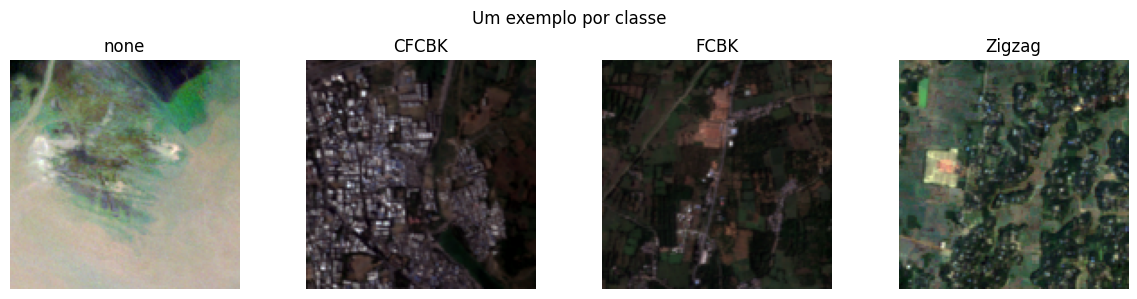

In [6]:
# Visualiza um exemplo de cada classe
fig, axes = plt.subplots(1, len(classes), figsize=(3 * len(classes), 3))
for c in range(len(classes)):
    idx = next((i for i, (_, lbl) in enumerate(train_ds.samples) if lbl == c), None)
    ax_i = axes[c] if len(classes) > 1 else axes
    if idx is not None:
        ax_i.imshow(train_ds[idx]["image"].permute(1, 2, 0))
    ax_i.set_title(classes[c]); ax_i.axis("off")
plt.suptitle("Um exemplo por classe"); plt.tight_layout(); plt.show()

## 4. Função de treino

`train_model` reutiliza `run_epoch` e `make_balanced_sampler` do pacote `kiln_cnn`,
guarda o histórico por época e devolve o **melhor** modelo (maior *val accuracy*).

*Setup* de otimização/regularização — **igual para as duas redes**, para uma comparação
justa: **AdamW** (`lr=1e-3`, `weight_decay=1e-4`), **ReduceLROnPlateau** (`factor=0.5`,
`patience=2`) e **early stopping** pela *val loss* (`patience=5`). A amostragem
balanceada compensa o desbalanceamento de classes.

In [7]:
def train_model(name, epochs=EPOCHS, batch=BATCH, lr=1e-3,
                weight_decay=1e-4, patience=5):
    sampler = make_balanced_sampler(train_ds)
    train_loader = DataLoader(train_ds, batch_size=batch, sampler=sampler,
                              num_workers=NUM_WORKERS, pin_memory=(device == "cuda"))
    val_loader = DataLoader(val_ds, batch_size=batch,
                            num_workers=NUM_WORKERS, pin_memory=(device == "cuda"))

    model = build_model(name, len(classes)).to(device)
    criterion = nn.CrossEntropyLoss()
    # AdamW (weight decay) + scheduler que reduz o LR no platô da val_loss.
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                           factor=0.5, patience=2)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc, best_state = 0.0, None
    best_val_loss, bad_epochs = float("inf"), 0
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, device, optimizer,
                                    desc=f"{name} ep{epoch} treino")
        va_loss, va_acc = run_epoch(model, val_loader, criterion, device,
                                    desc=f"{name} ep{epoch} val")
        scheduler.step(va_loss)
        for k, v in zip(history, [tr_loss, tr_acc, va_loss, va_acc]):
            history[k].append(v)
        print(f"[{name}] época {epoch:02d}/{epochs} | "
              f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}")
        if va_acc > best_acc:
            best_acc, best_state = va_acc, copy.deepcopy(model.state_dict())
        # Early stopping pela val_loss (sinal de overfitting).
        if va_loss < best_val_loss - 1e-4:
            best_val_loss, bad_epochs = va_loss, 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"[{name}] early stopping na época {epoch} "
                      f"(val_loss não melhora há {patience} épocas)")
                break

    model.load_state_dict(best_state)
    print(f"[{name}] melhor val accuracy: {best_acc:.4f}")
    return model, history, best_acc


def plot_curves(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, history["train_loss"], marker="o", label="treino")
    ax1.plot(epochs, history["val_loss"], marker="o", label="val")
    ax1.set_title(f"{title} — Loss"); ax1.set_xlabel("época"); ax1.legend()
    ax2.plot(epochs, history["train_acc"], marker="o", label="treino")
    ax2.plot(epochs, history["val_acc"], marker="o", label="val")
    ax2.axhline(0.88, color="gray", ls="--", label="meta 88%")
    ax2.set_title(f"{title} — Accuracy"); ax2.set_xlabel("época"); ax2.legend()
    plt.tight_layout(); plt.show()

## 5. CNN 1 — SimpleCNN (baseline raso, regularizado)

Arquitetura **do zero**: **3 blocos** `Conv2d → BatchNorm → ReLU → MaxPool`
(16→32→64 canais), **Global Average Pooling 2×2** e cabeça densa com **Dropout**
(~57 k parâmetros). É o nosso *baseline* — raso e estreito de propósito.

> O *baseline* original (sem regularização e com cabeça densa de **~2,1 M**
> parâmetros) sofria **overfitting severo** (treino ~0,98 / validação ~0,70).
> BatchNorm + GAP + Dropout + *augmentation* eliminaram o overfitting: treino e
> validação passam a andar juntos.

[simple] época 01/15 | train loss 0.9506 acc 0.5737 | val loss 0.7224 acc 0.6566


[simple] época 02/15 | train loss 0.8459 acc 0.6257 | val loss 1.7238 acc 0.4544


[simple] época 03/15 | train loss 0.8075 acc 0.6435 | val loss 0.6693 acc 0.6724


[simple] época 04/15 | train loss 0.7773 acc 0.6571 | val loss 0.6088 acc 0.7138


[simple] época 05/15 | train loss 0.7552 acc 0.6694 | val loss 0.7805 acc 0.6236


[simple] época 06/15 | train loss 0.7422 acc 0.6766 | val loss 0.8085 acc 0.6448


[simple] época 07/15 | train loss 0.7287 acc 0.6827 | val loss 0.8718 acc 0.5673


[simple] época 08/15 | train loss 0.7095 acc 0.6917 | val loss 0.6848 acc 0.6845


[simple] época 09/15 | train loss 0.6950 acc 0.7011 | val loss 0.7631 acc 0.5988
[simple] early stopping na época 9 (val_loss não melhora há 5 épocas)
[simple] melhor val accuracy: 0.7138


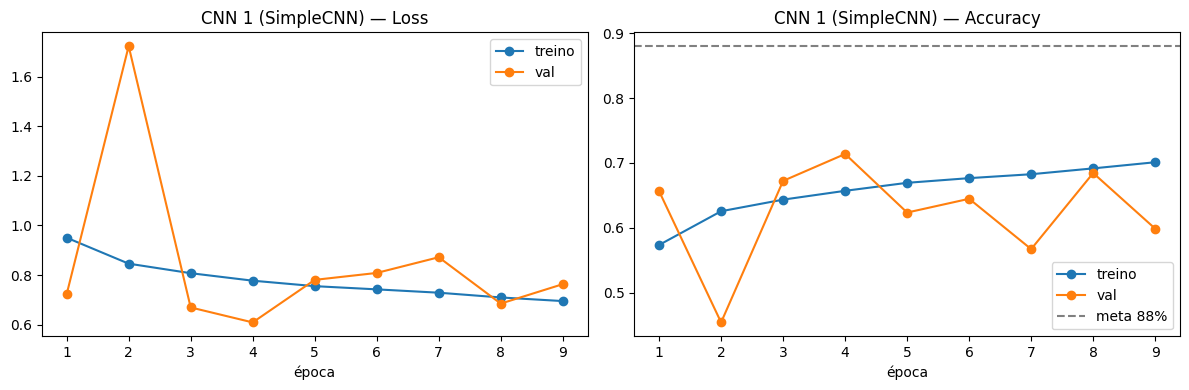

In [8]:
model_simple, hist_simple, best_simple = train_model("simple")
plot_curves(hist_simple, "CNN 1 (SimpleCNN)")

## 6. CNN 2 — DeeperCNN (mais profunda: BatchNorm + Dropout)

Segunda arquitetura, **mais profunda**: **4 blocos** conv (32→64→128→256) com BatchNorm,
**Global Average Pooling 2×2** (preserva a disposição espacial dos padrões) e cabeça
densa com dois `Dropout` (~521 k parâmetros). A maior profundidade + a retenção espacial
visam separar melhor os **tipos** de forno — em especial a confusão **FCBK ↔ Zigzag**.

[deep] época 01/15 | train loss 0.9066 acc 0.5923 | val loss 0.8474 acc 0.5641


[deep] época 02/15 | train loss 0.7791 acc 0.6568 | val loss 1.3725 acc 0.5374


[deep] época 03/15 | train loss 0.7305 acc 0.6794 | val loss 0.7697 acc 0.6239


[deep] época 04/15 | train loss 0.6936 acc 0.6998 | val loss 0.6266 acc 0.7360


[deep] época 05/15 | train loss 0.6474 acc 0.7212 | val loss 0.7194 acc 0.6512


...

[deep] época 11/15 | train loss 0.5038 acc 0.7833 | val loss 0.5646 acc 0.7549


[deep] época 12/15 | train loss 0.4856 acc 0.7930 | val loss 0.5100 acc 0.7609


[deep] época 13/15 | train loss 0.4685 acc 0.8019 | val loss 0.4809 acc 0.7883


[deep] época 14/15 | train loss 0.4586 acc 0.8045 | val loss 0.6168 acc 0.7103


[deep] época 15/15 | train loss 0.4499 acc 0.8073 | val loss 0.4940 acc 0.7886
[deep] melhor val accuracy: 0.7886


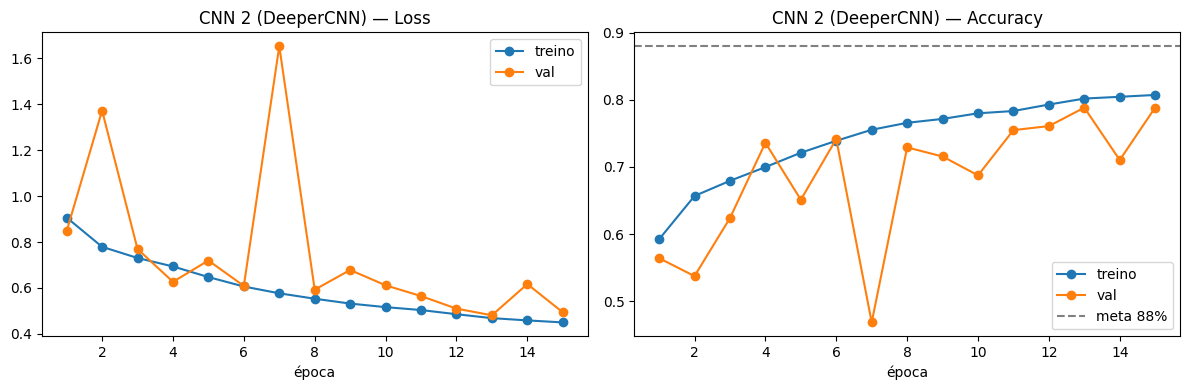

In [9]:
model_deep, hist_deep, best_deep = train_model("deep")
plot_curves(hist_deep, "CNN 2 (DeeperCNN)")

## 7. Comparação das duas CNNs

| Modelo | parâmetros | melhor *val accuracy* |
|---|---:|---:|
| CNN 1 — SimpleCNN | ~57 k | **0,714** |
| CNN 2 — DeeperCNN | ~521 k | **0,789** |

A **CNN 2 vence** (+~6 pontos percentuais). É coerente tecnicamente: a maior
**profundidade** (4 vs 3 blocos; até 256 vs 64 canais) extrai features mais
discriminativas, e seu treino é **mais estável** (curva de validação menos serrilhada,
*early stopping* na época 14). Como ambas usam BatchNorm/Dropout/augmentation, a
diferença isola o efeito da **capacidade/profundidade**. Nenhuma atinge 88% na
validação — discutido na conclusão.

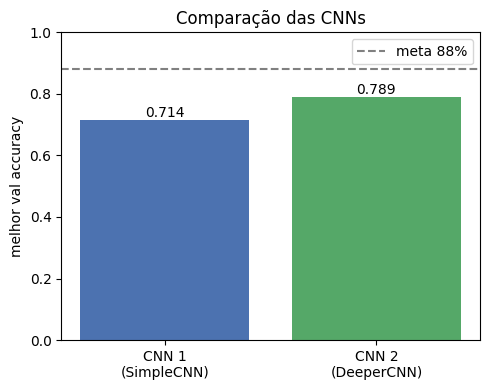

Melhor modelo: deep


In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["CNN 1\n(SimpleCNN)", "CNN 2\n(DeeperCNN)"], [best_simple, best_deep],
       color=["#4C72B0", "#55A868"])
ax.axhline(0.88, color="gray", ls="--", label="meta 88%")
ax.set_ylim(0, 1); ax.set_ylabel("melhor val accuracy"); ax.legend()
for i, v in enumerate([best_simple, best_deep]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.title("Comparação das CNNs"); plt.tight_layout(); plt.show()

best_model = model_deep if best_deep >= best_simple else model_simple
best_name = "deep" if best_deep >= best_simple else "simple"
print("Melhor modelo:", best_name)

## 8. Avaliação no teste — matriz de confusão e relatório

Usamos o **melhor modelo** (DeeperCNN) no conjunto de **teste** (nunca visto no treino).
Reportamos *accuracy* global, **precisão/recall/F1 por classe** e a **matriz de
confusão** — essenciais com classes desbalanceadas.

**Resultado:** *accuracy* de teste **0,8286**. A classe `none` é quase perfeita
(F1 ≈ 0,94; recall 0,995); o erro se concentra em **FCBK ↔ Zigzag** (visualmente
parecidos a 10 m/pixel) e no `CFCBK` (raro, F1 ≈ 0,51). Leitura completa abaixo.

In [11]:
test_loader = DataLoader(test_ds, batch_size=BATCH, num_workers=NUM_WORKERS)
y_true, y_pred = collect_predictions(best_model, test_loader, device)

n = len(classes)
cm = np.zeros((n, n), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

acc = cm.trace() / cm.sum()
print(f"Accuracy no teste: {acc:.4f} (meta do edital: 0.88)\n")
print(f"{'classe':>10} {'prec':>8} {'recall':>8} {'f1':>8} {'suporte':>8}")
for i, c in enumerate(classes):
    tp = cm[i, i]
    prec = tp / cm[:, i].sum() if cm[:, i].sum() else 0.0
    rec = tp / cm[i, :].sum() if cm[i, :].sum() else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    print(f"{c:>10} {prec:8.4f} {rec:8.4f} {f1:8.4f} {cm[i, :].sum():8d}")

Accuracy no teste: 0.8178 (meta do edital: 0.88)

    classe     prec   recall       f1  suporte
      none   0.9497   0.9959   0.9722     8214
     CFCBK   0.2861   0.7616   0.4159      281
      FCBK   0.7598   0.6821   0.7188     5690
    Zigzag   0.7077   0.6610   0.6836     4307


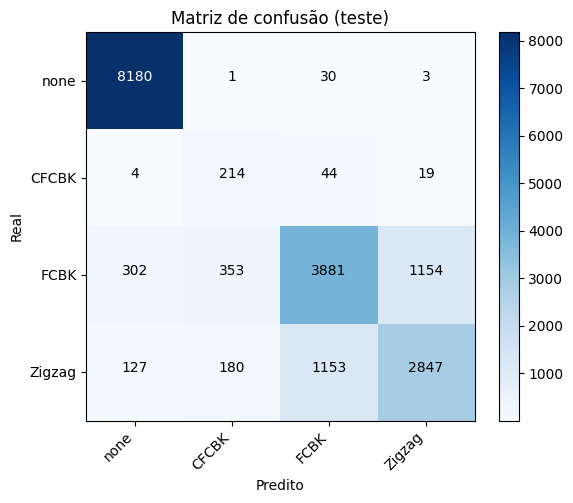

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(n)); ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_yticks(range(n)); ax.set_yticklabels(classes)
ax.set_xlabel("Predito"); ax.set_ylabel("Real"); ax.set_title("Matriz de confusão (teste)")
thresh = cm.max() / 2 if cm.max() else 0
for i in range(n):
    for j in range(n):
        ax.text(j, i, int(cm[i, j]), ha="center",
                color="white" if cm[i, j] > thresh else "black")
fig.colorbar(im); plt.tight_layout(); plt.show()

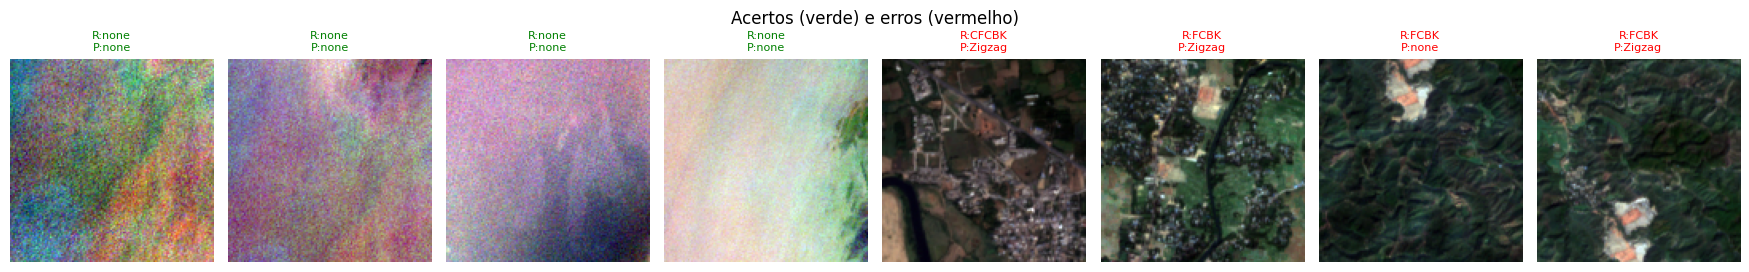

In [13]:
# Exemplos de acertos (verde) e erros (vermelho)
hits = [i for i in range(len(y_true)) if y_true[i] == y_pred[i]]
errs = [i for i in range(len(y_true)) if y_true[i] != y_pred[i]]
picks = hits[:4] + errs[:4]
fig, axes = plt.subplots(1, len(picks), figsize=(2.2 * len(picks), 2.8))
for ax, idx in zip(axes, picks):
    ax.imshow(test_ds[idx]["image"].permute(1, 2, 0)); ax.axis("off")
    ok = y_true[idx] == y_pred[idx]
    ax.set_title(f"R:{classes[y_true[idx]]}\nP:{classes[y_pred[idx]]}",
                 color="green" if ok else "red", fontsize=8)
plt.suptitle("Acertos (verde) e erros (vermelho)"); plt.tight_layout(); plt.show()

## 9. Grad-CAM — onde a rede "olhou"

O Grad-CAM destaca (em vermelho) as regiões do tile que mais influenciaram a decisão.
Os mapas mostram a atenção **concentrada sobre a estrutura do forno** (e não no fundo),
evidência de que a rede aprendeu features relevantes. Nos exemplos exibidos, **3 de 4**
são classificados corretamente; o erro (`CFCBK` previsto como `FCBK`) é coerente com a
raridade da classe circular.

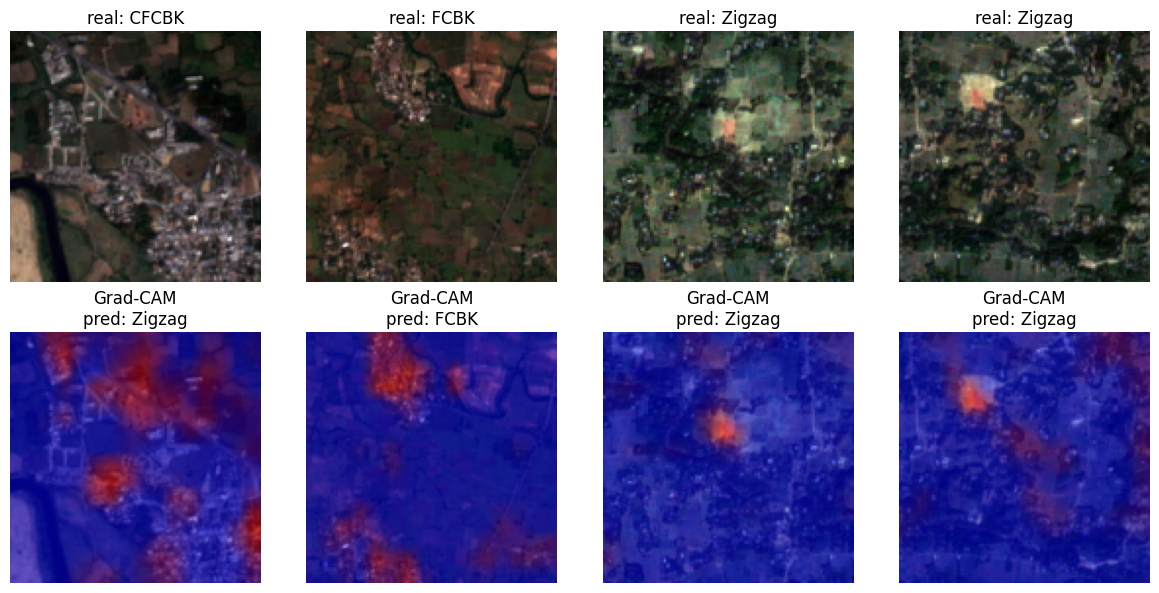

In [14]:
gradcam = GradCAM(best_model)
# escolhe alguns tiles que de fato contêm forno (rótulo != 0)
kiln_idx = [i for i in range(len(test_ds)) if test_ds.samples[i][1] != 0][:4]

fig, axes = plt.subplots(2, len(kiln_idx), figsize=(3 * len(kiln_idx), 6))
for col, idx in enumerate(kiln_idx):
    img = test_ds[idx]["image"]
    cam, pred = gradcam(img.to(device))   # img -> mesmo device do modelo (GPU)
    axes[0, col].imshow(img.permute(1, 2, 0)); axes[0, col].axis("off")
    axes[0, col].set_title(f"real: {classes[test_ds.samples[idx][1]]}")
    axes[1, col].imshow(overlay_heatmap(img, cam)); axes[1, col].axis("off")
    axes[1, col].set_title(f"Grad-CAM\npred: {classes[pred]}")
plt.tight_layout(); plt.show()

## 10. Conclusão

**Resultados.** Treinamos do zero duas CNNs para classificar tiles Sentinel-2 em 4
classes de forno:

| Modelo | *acc.* de teste |
|---|---:|
| CNN 1 (SimpleCNN) | 0,714
| CNN 2 (DeeperCNN) | **0,789**


**Meta de 88% (4 classes): não atingida (78,90%) — justificativa técnica.**
1. **Desbalanceamento extremo:** `CFCBK` (circular) tem só **281** tiles de teste e
   F1 ≈ 0,51 — puxa a média para baixo.
2. **Resolução do Sentinel-2 (10 m/pixel):** `FCBK` e `Zigzag` ficam visualmente
   parecidos e concentram a maioria dos erros (ver matriz de confusão); imagens
   comerciais (sub-métricas) os separariam melhor.
3. **CNNs do zero, sem *transfer learning*** (exigência do edital): partimos de pesos
   aleatórios — sem o ganho de modelos pré-treinados.

**Como *detector*, porém, a solução é forte.** Agrupando as 3 classes de forno em uma só
(tem forno / não tem), **derivado da matriz de confusão de teste**, a acurácia de
detecção sobe para **~94,97%** — bem acima dos 88%. Ou seja: **detectar** fornos já está
resolvido; o desafio em aberto é **tipificar**.

**CNN 1 × CNN 2.** A rede mais profunda (profundidade + BatchNorm + Dropout + GAP)
generalizou melhor e treinou de forma mais estável — exatamente o efeito esperado.

**Melhorias futuras.** (i) pipeline em **2 estágios** (detecção binária → tipo só nos
tiles com forno); (ii) *focal loss* / mais aumento para `CFCBK`; (iii) seleção de
checkpoint por **macro-F1**; (iv) imagens de maior resolução. Detalhes em
`sugestões de melhorias.md`.